## **MNIST alphanumeric number-plate reading application**

**Group 8**

**Configuration Setup**

In [ ]:
!pip -q install tensorflow_datasets

In [ ]:
import os, io, glob, math, json, random, time, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow import keras
from tensorflow.keras import layers
import hashlib, datetime, traceback
from sklearn.model_selection import train_test_split

In [ ]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", gpus if gpus else "NONE - go to Runtime > Change runtime type > T4 GPU")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
CFG = dict(
    # data
    n_train_max   = 220_000,   # subsample of EMNIST train (full = 697,932). Lower = faster.
    n_test_max    = 60_000,    # subsample of EMNIST test  (full = 116,323)
    val_fraction  = 0.10,
    img_size      = 28,
    n_classes     = 36,        # 0-9 + A-Z, case-merged

    # training
    batch_size    = 256,
    epochs_mlp    = 6,
    epochs_cnn    = 18,
    epochs_ft     = 6,         # fine-tune epochs for domain adaptation
    lr            = 1e-3,
    lr_ft         = 2e-4,

    # plate simulation
    plate_len     = 7,         # characters per plate
    n_eval_plates = 400,       # synthetic plates used for end-to-end evaluation
)

CHARS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
IDX2CHAR = {i: c for i, c in enumerate(CHARS)}
CHAR2IDX = {c: i for i, c in enumerate(CHARS)}
assert len(CHARS) == CFG["n_classes"]

# Glyph pairs that are visually ambiguous and therefore expensive in production.
# Many jurisdictions omit I, O, Q from issued plates for exactly this reason.
CONFUSABLE_PAIRS = [("0","O"), ("1","I"), ("5","S"), ("8","B"), ("2","Z"),
                    ("6","G"), ("7","T"), ("4","A"), ("D","O"), ("U","V")]

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(json.dumps(CFG, indent=2))

{
  "n_train_max": 220000,
  "n_test_max": 60000,
  "val_fraction": 0.1,
  "img_size": 28,
  "n_classes": 36,
  "batch_size": 256,
  "epochs_mlp": 6,
  "epochs_cnn": 18,
  "epochs_ft": 6,
  "lr": 0.001,
  "lr_ft": 0.0002,
  "plate_len": 7,
  "n_eval_plates": 400
}


EMNIST loader: local Kaggle CSVs first, network routes as fallback

In [ ]:
RAW_CLASSES = 62                      # ByClass: 0-9, A-Z, a-z
EXPECTED_N  = {"train": 697_932, "test": 116_323}

# ---- manual ingest settings ----
CSV_DIR   = "/content"     # where emnist-byclass-{train,test}.csv live
EXACT_IDX = False          # True = read every row so orig_idx are true file line
                           # numbers (slower). False = pre-sample while parsing.

# EMNIST ships column-major, so a transpose is expected. But we do NOT assume every
# route shares that convention - a library could start correcting it upstream. Instead
# the guard decides, and provenance records what it decided.
#   "auto"     -> try transposed and untransposed, keep whichever passes the guard
#   True/False -> pin it (strict mode; the guard still has to pass)
ORIENTATION_MODE   = "auto"
EXPECTED_TRANSPOSE = True  # what we expect; a mismatch warns loudly, never silently

PROVENANCE = {"orientation_verified": False}


# ---------------------------------------------------------------- geometry --
def _ink_profile(imgs):
    """Normalised ink-mass statistics for a stack of glyphs."""
    m = imgs.astype(np.float32).reshape(-1, 28, 28).mean(0)
    m = m / (m.sum() + 1e-9)
    ys, xs = np.mgrid[0:28, 0:28]
    cy, cx = (m * ys).sum(), (m * xs).sum()
    return dict(
        spread_y=float(np.sqrt((m * (ys - cy) ** 2).sum())),
        spread_x=float(np.sqrt((m * (xs - cx) ** 2).sum())),
        top=float(m[:14].sum()),
        bottom=float(m[14:].sum()),
    )


def assert_upright(X, y_raw, margin=1.05, verbose=True):
    """Fail loudly if glyph orientation has regressed.

    Three falsifiable geometric claims. Transposing an image reflects it across
    the main diagonal, which breaks all three at once. Called inside the loader
    so a later refactor cannot bypass it.
    """
    # raw ByClass labels: 0-9 digits, 10-35 uppercase A-Z, 36-61 lowercase
    idx = {"1": 1,
           "T": 10 + (ord("T") - ord("A")),
           "L": 10 + (ord("L") - ord("A"))}

    report, failures = {}, []
    for ch, k in idx.items():
        sel = X[y_raw == k]
        if len(sel) < 30:
            raise AssertionError(
                f"orientation check needs >=30 samples of '{ch}' (class {k}), found {len(sel)}. "
                "Either n_train_max is too small for a reliable check, or the label mapping "
                "is wrong (is this really the ByClass split?).")
        report[ch] = _ink_profile(sel[:1500])
        report[ch]["n"] = int(len(sel))

    # 1) '1' is a tall narrow stroke
    r = report["1"]
    r["aspect"] = r["spread_y"] / max(r["spread_x"], 1e-6)
    if r["aspect"] < 1.25:
        failures.append(f"'1' aspect (vertical/horizontal ink spread) = {r['aspect']:.2f}, expected > 1.25")

    # 2) 'T' carries its bar across the top
    r = report["T"]
    if r["top"] < r["bottom"] * margin:
        failures.append(f"'T' top ink {r['top']:.3f} vs bottom {r['bottom']:.3f} - not top-heavy")

    # 3) 'L' carries its foot along the bottom
    r = report["L"]
    if r["bottom"] < r["top"] * margin:
        failures.append(f"'L' bottom ink {r['bottom']:.3f} vs top {r['top']:.3f} - not bottom-heavy")

    if verbose:
        print("  orientation checks:")
        print(f"    '1' tall-not-wide : aspect {report['1']['aspect']:.2f}  (need > 1.25)")
        print(f"    'T' top-heavy     : {report['T']['top']:.3f} vs {report['T']['bottom']:.3f}")
        print(f"    'L' bottom-heavy  : {report['L']['bottom']:.3f} vs {report['L']['top']:.3f}")

    if failures:
        raise AssertionError(
            "EMNIST ORIENTATION CHECK FAILED - refusing to return data.\n  - "
            + "\n  - ".join(failures)
            + "\n\nAlmost certainly the transpose was removed or applied twice. "
              "EMNIST is stored column-major; images need np.transpose(X, (0, 2, 1, 3)) "
              "exactly once. See ORIENTATION_MODE in this cell.")
    return report


def _finalise(X, y, max_items, mode=None):
    """Canonicalise, subsample, then let the guard pick the orientation."""
    mode = ORIENTATION_MODE if mode is None else mode
    X = to_canonical_uint8(X)          # resize + grayscale + uint8, one definition
    y = np.asarray(y, np.int32).ravel()
    assert len(X) == len(y), f"length mismatch {len(X)} vs {len(y)}"
    assert y.min() >= 0 and y.max() < RAW_CLASSES, f"labels outside 0-{RAW_CLASSES-1}"

    # Original positions within the source split. Kept so splits can be proven
    # disjoint by index later - without these there is nothing to check.
    orig_idx = np.arange(len(X), dtype=np.int64)

    if max_items and len(X) > max_items:
        # Stratified subsample: a plain rng.choice only matches class proportions
        # in expectation, which is not what "preserving class proportions" means.
        keep, _ = train_test_split(orig_idx, train_size=max_items,
                                   stratify=y, random_state=SEED)
        keep = np.sort(keep)
        X, y, orig_idx = X[keep], y[keep], orig_idx[keep]
        subsample = "stratified"
    else:
        subsample = "none (full split)"

    candidates = [True, False] if mode == "auto" else [bool(mode)]
    failures = {}
    for t in candidates:
        Xc = np.transpose(X, (0, 2, 1, 3)) if t else X
        try:
            report = assert_upright(Xc, y, verbose=False)
        except AssertionError as e:
            failures[t] = str(e).split("\n")[1:4]
            continue
        if t != EXPECTED_TRANSPOSE:
            print(f"  !! WARNING: this route needed transpose={t}, expected "
                  f"{EXPECTED_TRANSPOSE}. The source's layout convention has changed. "
                  f"Recorded in provenance - explain it in the report.")
        return Xc, y, orig_idx, dict(transpose_applied=t, orientation_mode=mode,
                                     subsample=subsample, orientation_report=report)

    raise AssertionError(
        "EMNIST ORIENTATION CHECK FAILED - refusing to return data.\n"
        f"Tried transpose={candidates} and no option produced upright glyphs.\n"
        + json.dumps(failures, indent=2, default=str) +
        "\n\nThis is not a transpose bug - both orientations failed, so the data itself "
        "is wrong. Check the label mapping (ByClass must be 0-9, A-Z, a-z in that order) "
        "and that you loaded emnist-BYCLASS, not balanced/letters/digits.")


# ------------------------------------------------- route 1/3: local CSV -----
def _find_emnist_csv(split):
    """Locate emnist-byclass-{split}.csv, listing what IS present if it is not."""
    names = [f"emnist-byclass-{split}.csv", f"emnist-byclass-{split}.CSV"]
    roots = [CSV_DIR, "/content", "/content/drive/MyDrive",
             "/root/.cache/kagglehub", "."]
    seen = set()
    for root in roots:
        if root in seen or not os.path.isdir(root):
            continue
        seen.add(root)
        for nm in names:
            hits = (glob.glob(os.path.join(root, nm))
                    + glob.glob(os.path.join(root, "**", nm), recursive=True))
            if hits:
                return hits[0]
    present = sorted(os.path.basename(f) for f in glob.glob(f"{CSV_DIR}/*"))[:15]
    raise FileNotFoundError(
        f"emnist-byclass-{split}.csv not found.\n"
        f"  searched: {sorted(seen)}\n"
        f"  files in {CSV_DIR}: {present or '(empty)'}\n"
        "  need: emnist-byclass-train.csv and emnist-byclass-test.csv\n"
        "  if you uploaded a zip:  !unzip -o /content/archive.zip -d /content")


def _load_kaggle_csv(split, max_items):
    path = _find_emnist_csv(split)
    print(f"  reading {os.path.basename(path)} "
          f"({os.path.getsize(path)/1e6:,.0f} MB) - a few minutes for the train file")

    # Kaggle's files have no header row, but mirrors vary. Probe rather than assume.
    probe = pd.read_csv(path, header=None, nrows=1)
    has_header = not pd.api.types.is_numeric_dtype(probe.iloc[:, 0])
    if has_header:
        print("  header row detected, skipping it")

    # Read as uint8: labels are 0-61 and pixels 0-255, so both fit, and it uses
    # ~8x less memory than pandas' default int64 across 700k x 785 values.
    frac = 1.0 if EXACT_IDX else min(
        1.0, (max_items or EXPECTED_N[split]) / EXPECTED_N[split] * 1.25)

    parts, rows = [], 0
    for chunk in pd.read_csv(path, header=0 if has_header else None,
                             chunksize=100_000, dtype=np.uint8):
        rows += len(chunk)
        parts.append(chunk.sample(frac=frac, random_state=SEED) if frac < 1.0 else chunk)
    df = pd.concat(parts, ignore_index=True)
    print(f"  {rows:,} rows in file -> {len(df):,} parsed")

    if df.shape[1] != 785:
        raise ValueError(
            f"expected 785 columns (1 label + 784 pixels), got {df.shape[1]}. "
            "This is not the byclass CSV.")

    labels = df.iloc[:, 0].to_numpy()
    if labels.max() >= RAW_CLASSES:
        raise ValueError(
            f"labels reach {labels.max()}, expected < {RAW_CLASSES}. "
            "Looks like balanced/letters/digits rather than byclass.")
    if max_items and len(df) < max_items:
        print(f"  !! only {len(df):,} rows available, {max_items:,} requested - using all")

    return (df.iloc[:, 1:].to_numpy(), labels,
            dict(library=f"pandas {pd.__version__}",
                 uri=f"local CSV (kaggle:crawford/emnist) -> {path}",
                 prefiltered=bool(frac < 1.0)))


# ---------------------------------------------- route 2/3: torchvision ------
def _load_torchvision(split, max_items):
    import torchvision
    from torchvision import datasets
    ds = datasets.EMNIST(root="./emnist_data", split="byclass",
                         train=(split == "train"), download=True)
    return ds.data.numpy(), ds.targets.numpy(), dict(
        library=f"torchvision {torchvision.__version__}",
        uri="https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)")


# ----------------------------------------------------- route 3/3: TFDS ------
def _load_tfds(split, max_items):
    import tensorflow_datasets as tfds
    ds, info = tfds.load("emnist/byclass", split=split, as_supervised=True,
                         with_info=True, shuffle_files=True)
    ds = ds.shuffle(100_000, seed=SEED, reshuffle_each_iteration=False)
    if max_items:
        ds = ds.take(int(max_items * 1.05))
    xs, ys = [], []
    for xb, yb in tfds.as_numpy(ds.batch(8192)):
        xs.append(xb); ys.append(yb)
    return np.concatenate(xs), np.concatenate(ys), dict(
        library=f"tensorflow_datasets {tfds.__version__}",
        uri=f"tfds:emnist/byclass:{info.version}")


# --------------------------------------------------------------- driver -----
# Local CSVs first (no network, fully reproducible for a demo), then the
# download routes so the notebook still runs on a machine without the files.
ROUTES = [("kaggle_csv",  _load_kaggle_csv),
          ("torchvision", _load_torchvision),
          ("tfds",        _load_tfds)]


def load_emnist(split, max_items=None, prefer=None):
    order = prefer or [r[0] for r in ROUTES]
    attempts = []
    for name in order:
        fn = dict(ROUTES)[name]
        print(f"[{split}] trying route: {name} ...")
        try:
            t0 = time.time()
            Xr, yr, detail = fn(split, max_items)
            X, y, oidx, ometa = _finalise(Xr, yr, max_items)
            secs = time.time() - t0
            print(f"  OK  {len(X):,} images from '{name}' in {secs:.1f}s")
            PROVENANCE[split] = dict(
                route=name, **detail, n_loaded=int(len(X)),
                raw_classes=RAW_CLASSES, **ometa,
                seconds=round(secs, 1), attempts_before_success=attempts,
                sha256_first_2k=hashlib.sha256(X[:2000].tobytes()).hexdigest()[:16],
                sha256_orig_idx=hashlib.sha256(oidx.tobytes()).hexdigest()[:16],
                loaded_at_utc=datetime.datetime.utcnow().isoformat(timespec="seconds"),
            )
            return X, y, oidx
        except AssertionError:
            raise                     # orientation failure is never a fallback case
        except Exception as e:
            msg = f"{type(e).__name__}: {str(e)[:120]}"
            print(f"  FAILED ({msg}) -> next route")
            attempts.append({name: msg})
    raise RuntimeError(
        "All EMNIST routes failed.\n" + json.dumps(attempts, indent=2) +
        "\n\nManual fallback: download emnist-byclass-train.csv and emnist-byclass-test.csv "
        "from kaggle.com/datasets/crawford/emnist and upload them to /content.")


# ------------------------------------------------------- preflight check ----
print("route order:", [r[0] for r in ROUTES])
for _s in ("train", "test"):
    try:
        _p = _find_emnist_csv(_s)
        print(f"  {_s:>5}: {_p}  ({os.path.getsize(_p)/1e6:,.0f} MB)")
    except FileNotFoundError as e:
        print(f"  {_s:>5}: NOT FOUND - will fall through to torchvision/TFDS")
        print("   ", str(e).splitlines()[2])


route order: ['kaggle_csv', 'torchvision', 'tfds']
  train: /content/emnist-byclass-train.csv  (67 MB)
   test: /content/emnist-byclass-test.csv  (103 MB)


To define the input contract if missing + make the CSV route fail honestly

In [ ]:
# --- 1. input contract (needed by _finalise on every route) ------------------
if "to_canonical_uint8" not in globals():
    print("defining input contract (its cell was not run this session)")

    INPUT_SPEC = dict(height=28, width=28, channels=1,
                      dtype="float32", vmin=0.0, vmax=1.0, storage_dtype="uint8")

    def to_canonical_uint8(X):
        X = np.asarray(X)
        if X.ndim == 2 and X.shape[1] == 784: X = X.reshape(-1, 28, 28)
        elif X.ndim == 2:                     X = X[None, ...]
        if X.ndim == 3:                       X = X[..., None]
        if X.ndim != 4:
            raise ValueError(f"cannot interpret shape {X.shape} as images")
        if X.shape[-1] == 3:
            X = (X[..., :3] * np.array([0.299, 0.587, 0.114])).sum(-1, keepdims=True)
        elif X.shape[-1] != 1:
            raise ValueError(f"expected 1 or 3 channels, got {X.shape[-1]}")
        h, w = X.shape[1], X.shape[2]
        if (h, w) != (28, 28):
            print(f"  resizing {h}x{w} -> 28x28")
            interp = cv2.INTER_AREA if (h > 28 or w > 28) else cv2.INTER_CUBIC
            X = np.stack([cv2.resize(im.squeeze().astype(np.uint8), (28, 28),
                                     interpolation=interp) for im in X])[..., None]
        if X.dtype != np.uint8:
            X = np.clip(X, 0, 255).astype(np.uint8)
        assert X.shape[1:] == (28, 28, 1) and X.dtype == np.uint8
        return X

    def normalize(x):
        if isinstance(x, np.ndarray):
            if x.dtype != np.uint8:
                raise TypeError(f"normalize() expects uint8, got {x.dtype}")
            return x.astype(np.float32) / 255.0
        if x.dtype != tf.uint8:
            raise TypeError(f"normalize() expects tf.uint8, got {x.dtype}")
        return tf.cast(x, tf.float32) / 255.0

    def assert_input_contract(x, name="batch"):
        arr = x.numpy() if hasattr(x, "numpy") else np.asarray(x)
        bad = []
        if arr.ndim != 4:                  bad.append(f"ndim {arr.ndim}, expected 4")
        elif arr.shape[1:] != (28, 28, 1): bad.append(f"shape {arr.shape[1:]}")
        if arr.dtype != np.float32:        bad.append(f"dtype {arr.dtype}")
        lo, hi = float(arr.min()), float(arr.max())
        if lo < -1e-6 or hi > 1 + 1e-6:    bad.append(f"range [{lo:.3f},{hi:.3f}]")
        if hi <= 0.02 and arr.size > 100:  bad.append(f"max {hi:.5f} - double-normalised?")
        if bad:
            raise AssertionError(f"INPUT CONTRACT VIOLATED for '{name}': " + "; ".join(bad))
        return dict(name=name, shape=list(arr.shape), dtype=str(arr.dtype),
                    min=round(lo, 5), max=round(hi, 5), mean=round(float(arr.mean()), 5))
else:
    print("input contract already defined")


# --- 2. CSV route: validate row count instead of trusting the file -----------
def _load_kaggle_csv(split, max_items):
    path = _find_emnist_csv(split)
    print(f"  reading {os.path.basename(path)} ({os.path.getsize(path)/1e6:,.0f} MB)")

    probe = pd.read_csv(path, header=None, nrows=1)
    has_header = not pd.api.types.is_numeric_dtype(probe.iloc[:, 0])

    # No dtype coercion here: a truncated final row yields NaN, and forcing uint8
    # turns that into an opaque "Integer column has NA values" error.
    frac = 1.0 if EXACT_IDX else min(
        1.0, (max_items or EXPECTED_N[split]) / EXPECTED_N[split] * 1.25)

    parts, rows = [], 0
    for chunk in pd.read_csv(path, header=0 if has_header else None, chunksize=100_000):
        rows += len(chunk)
        parts.append(chunk.sample(frac=frac, random_state=SEED) if frac < 1.0 else chunk)
    df = pd.concat(parts, ignore_index=True)

    expected = EXPECTED_N[split]
    print(f"  {rows:,} rows read (file should contain {expected:,})")
    if rows < expected * 0.95:
        raise ValueError(
            f"{os.path.basename(path)} has {rows:,} rows but byclass-{split} has "
            f"{expected:,}. The file is truncated or is a different split - the "
            "upload probably did not finish. Re-download and re-upload it.")

    n_na = int(df.isna().any(axis=1).sum())
    if n_na:
        print(f"  !! {n_na} rows contain missing values - dropping them")
        df = df.dropna()

    if df.shape[1] != 785:
        raise ValueError(f"expected 785 columns, got {df.shape[1]}. Not the byclass CSV.")
    labels = df.iloc[:, 0].to_numpy().astype(np.int32)
    if labels.max() >= RAW_CLASSES:
        raise ValueError(f"labels reach {labels.max()}, expected < {RAW_CLASSES}. "
                         "Looks like balanced/letters/digits, not byclass.")

    pixels = df.iloc[:, 1:].to_numpy()
    pixels = np.clip(pixels, 0, 255).astype(np.uint8)
    return pixels, labels, dict(library=f"pandas {pd.__version__}",
                                uri=f"local CSV (kaggle:crawford/emnist) -> {path}",
                                prefiltered=bool(frac < 1.0))

ROUTES = [("kaggle_csv", _load_kaggle_csv),
          ("torchvision", _load_torchvision),
          ("tfds", _load_tfds)]
print("routes ready:", [r[0] for r in ROUTES])

defining input contract (its cell was not run this session)
routes ready: ['kaggle_csv', 'torchvision', 'tfds']


In [ ]:
X_tr_full, y_tr_full, idx_tr_full = load_emnist("train", CFG["n_train_max"])
X_te,      y_te,      idx_te      = load_emnist("test",  CFG["n_test_max"])

PROVENANCE["config"] = CFG
PROVENANCE["seed"]   = SEED
with open("provenance.json", "w") as f:
    json.dump(PROVENANCE, f, indent=2, default=str)

print("\n" + "="*66)
print("DATA PROVENANCE  (also written to provenance.json - cite this in the report)")
print("="*66)
for split in ("train", "test"):
    p = PROVENANCE[split]
    print(f"{split:>6}: route={p['route']:<12} n={p['n_loaded']:>7,}  "
          f"transpose={p['transpose_applied']}  hash={p['sha256_first_2k']}")
    print(f"        source: {p['uri']}")
    if p["attempts_before_success"]:
        print(f"        fell back after: {p['attempts_before_success']}")
print("="*66)

[train] trying route: kaggle_csv ...
  reading emnist-byclass-train.csv (67 MB)
  34,668 rows read (file should contain 697,932)
  FAILED (ValueError: emnist-byclass-train.csv has 34,668 rows but byclass-train has 697,932. The file is truncated or is a different split - ) -> next route
[train] trying route: torchvision ...


100%|██████████| 562M/562M [00:04<00:00, 130MB/s]


  OK  220,000 images from 'torchvision' in 53.7s
[test] trying route: kaggle_csv ...
  reading emnist-byclass-test.csv (163 MB)
  88,847 rows read (file should contain 116,323)
  FAILED (ValueError: emnist-byclass-test.csv has 88,847 rows but byclass-test has 116,323. The file is truncated or is a different split - th) -> next route
[test] trying route: torchvision ...
  OK  60,000 images from 'torchvision' in 0.1s

DATA PROVENANCE  (also written to provenance.json - cite this in the report)
 train: route=torchvision  n=220,000  transpose=True  hash=31ad91c785176726
        source: https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)
        fell back after: [{'kaggle_csv': 'ValueError: emnist-byclass-train.csv has 34,668 rows but byclass-train has 697,932. The file is truncated or is a different split - '}]
  test: route=torchvision  n= 60,000  transpose=True  hash=74ac3fc25427b3a6
        source: https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)

ACCEPTANCE GATE - ten samples plotted and checked before any training runs

  orientation checks:
    '1' tall-not-wide : aspect 2.07  (need > 1.25)
    'T' top-heavy     : 0.716 vs 0.284
    'L' bottom-heavy  : 0.693 vs 0.307


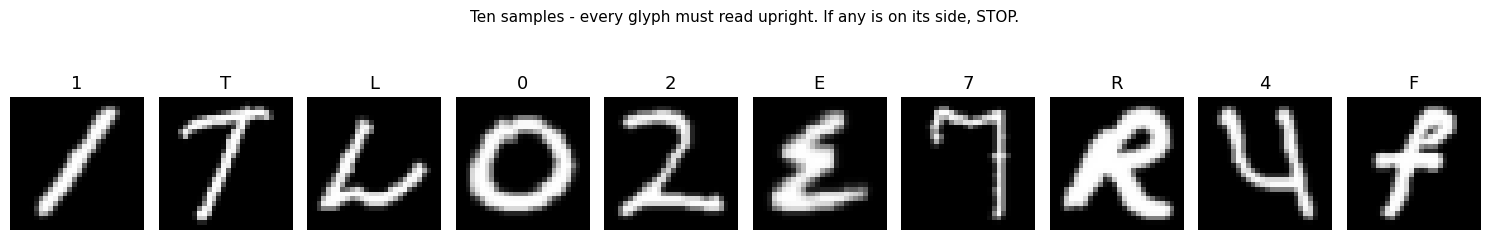

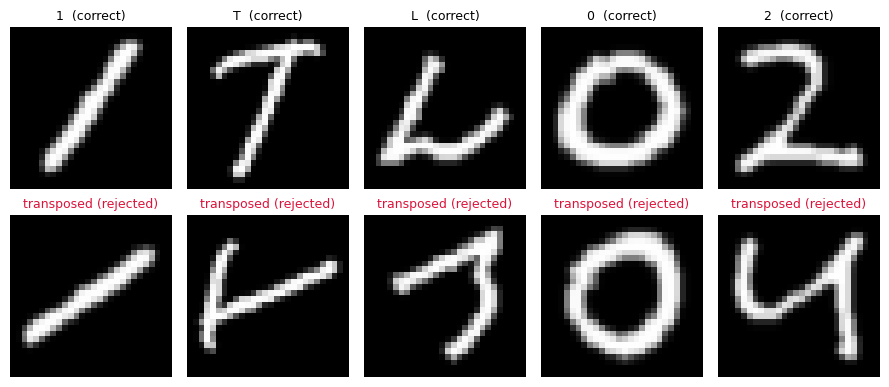


Guard self-test PASSED: transposed input is correctly rejected.
Orientation verified. Training is unlocked.


In [ ]:
report = assert_upright(X_tr_full, y_tr_full, verbose=True)   # raises if regressed

RAW_LABEL = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
rng = np.random.default_rng(SEED)
picks = [int(rng.choice(np.where(y_tr_full == k)[0]))
         for k in [1, 10+ord('T')-ord('A'), 10+ord('L')-ord('A'), 0, 2,
                   10+ord('E')-ord('A'), 7, 10+ord('R')-ord('A'), 4,
                   10+ord('F')-ord('A')]]

fig, axes = plt.subplots(1, 10, figsize=(15, 2.1))
for ax, i in zip(axes, picks):
    ax.imshow(X_tr_full[i].squeeze(), cmap="gray")
    ax.set_title(RAW_LABEL[y_tr_full[i]], fontsize=13); ax.axis("off")
plt.suptitle("Ten samples - every glyph must read upright. If any is on its side, STOP.",
             y=1.16, fontsize=11)
plt.tight_layout(); plt.show()

# Side-by-side proof of what the guard is actually catching
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for j, i in enumerate(picks[:5]):
    axes[0, j].imshow(X_tr_full[i].squeeze(), cmap="gray")
    axes[0, j].set_title(f"{RAW_LABEL[y_tr_full[i]]}  (correct)", fontsize=9)
    axes[1, j].imshow(X_tr_full[i].squeeze().T, cmap="gray")
    axes[1, j].set_title("transposed (rejected)", fontsize=9, color="crimson")
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

# Prove the guard actually fires - a check that never fails is not a check
try:
    assert_upright(np.transpose(X_tr_full[:20000], (0, 2, 1, 3)),
                   y_tr_full[:20000], verbose=False)
    raise SystemExit("GUARD IS BROKEN: it accepted transposed data. Do not train.")
except AssertionError:
    print("\nGuard self-test PASSED: transposed input is correctly rejected.")

PROVENANCE["orientation_verified"] = True
PROVENANCE["orientation_report"]   = report
with open("provenance.json", "w") as f:
    json.dump(PROVENANCE, f, indent=2, default=str)
print("Orientation verified. Training is unlocked.")


 Threshold calibration - does the guard have enough headroom on THIS data?



In [ ]:
def calibrate_guard(X, y, n=1500):
    idx = {"1": 1, "T": 10 + (ord("T")-ord("A")), "L": 10 + (ord("L")-ord("A"))}
    up, tr = {}, {}
    for ch, k in idx.items():
        sel = X[y == k][:n]
        up[ch] = _ink_profile(sel)
        tr[ch] = _ink_profile(np.transpose(sel, (0, 2, 1, 3)))

    tests = [
        ("'1' tall-not-wide", up["1"]["spread_y"]/up["1"]["spread_x"],
                              tr["1"]["spread_y"]/tr["1"]["spread_x"], 1.25),
        ("'T' top-heavy",     up["T"]["top"]/up["T"]["bottom"],
                              tr["T"]["top"]/tr["T"]["bottom"],        1.05),
        ("'L' bottom-heavy",  up["L"]["bottom"]/up["L"]["top"],
                              tr["L"]["bottom"]/tr["L"]["top"],        1.05),
    ]

    rows, weak = [], []
    for name, obs, cf, cur in tests:
        suggested = float(np.sqrt(max(obs, 1e-6) * max(cf, 1e-6)))   # midpoint in log space
        headroom  = obs / cur
        separation = obs / max(cf, 1e-6)
        rows.append(dict(test=name, observed=obs, transposed_counterfactual=cf,
                         current_threshold=cur, suggested_threshold=round(suggested, 3),
                         headroom_x=round(headroom, 2), separation_x=round(separation, 1)))
        if headroom < 1.20 or separation < 1.5:
            weak.append(name)

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print()
    if weak:
        print(f"TIGHT: {weak}")
        print("  Observed value sits too close to the threshold or to the transposed case.")
        print("  Raise the margin toward 'suggested_threshold', or swap that glyph for one")
        print("  with a stronger asymmetry (try 'J', 'F' or '7').")
    else:
        print("All three tests clear their thresholds with margin, and separate cleanly")
        print("from the transposed counterfactual. Guard is trustworthy on this data.")
    return df

calib = calibrate_guard(X_tr_full, y_tr_full)
PROVENANCE["guard_calibration"] = calib.to_dict("records")

             test  observed  transposed_counterfactual  current_threshold  suggested_threshold  headroom_x  separation_x
'1' tall-not-wide    2.0705                     0.4830             1.2500               1.0000      1.6600        4.3000
    'T' top-heavy    2.5187                     1.6153             1.0500               2.0170      2.4000        1.6000
 'L' bottom-heavy    2.2621                     0.4973             1.0500               1.0610      2.1500        4.5000

All three tests clear their thresholds with margin, and separate cleanly
from the transposed counterfactual. Guard is trustworthy on this data.


Case merge 62 -> 36, now that orientation is confirmed

In [ ]:
assert PROVENANCE["orientation_verified"], "Run the orientation gate cell first."

def merge_case(y):
    y = np.asarray(y)
    if y.max() < CFG["n_classes"]:          # idempotent: re-running this cell is safe
        return y.astype(np.int32)
    return np.where(y >= 36, y - 26, y).astype(np.int32)

if "y_te_raw" not in globals():
    y_te_raw = y_te.copy()      # pre-merge snapshot, saved once
y_tr_full, y_te = merge_case(y_tr_full), merge_case(y_te)

assert y_tr_full.max() < CFG["n_classes"] and y_te.max() < CFG["n_classes"]
assert set(np.unique(y_tr_full)) == set(range(CFG["n_classes"])), "not all 36 classes present"
print(f"train {X_tr_full.shape} labels {y_tr_full.min()}-{y_tr_full.max()}")
print(f"test  {X_te.shape}")

train (220000, 28, 28, 1) labels 0-35
test  (60000, 28, 28, 1)


Cross-route agreement - do two independent sources agree on label -> glyph?

In [ ]:
# The orientation guard verifies geometry. It does not verify that route A and
# route B index their classes identically (torchvision remaps labels for the
# 'letters' split, for instance). This catches that class of bug.
#
# WHAT THIS CHECK LEARNED THE HARD WAY (ML-36):
#   The first version failed on 'g'->'9' and 'o'->'0' and called it a mapping
#   mismatch. It was not. Those glyphs genuinely look alike, exactly as the
#   case partners c/C, i/I, p/P, s/S, v/V do. A real reordering bug does not
#   produce two failures out of sixty-one - it collapses the ENTIRE diagonal.
#   So the test is now on the diagonal itself, not on argmax identity.

RAW_LABEL = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

DIAG_FLOOR   = 0.50   # mean self-correlation below this = orderings disagree
SELF_OK      = 0.80   # a class correlating this well with itself is fine,
                      # whatever else it happens to resemble
RIVAL_MARGIN = 0.02   # a rival winning by less than this is a coin flip


def _case_partner(k):
    """Uppercase class for a lowercase one and vice versa. None for digits."""
    if 10 <= k <= 35: return k + 26
    if 36 <= k <= 61: return k - 26
    return None


def cross_route_check(n=6000, exclude=None):
    ref_route = PROVENANCE["test"]["route"]
    others = [r for r, _ in ROUTES if r != ref_route and r != (exclude or "")]
    Xa, ya = X_te[:n], y_te_raw[:n]

    for other in others:
        try:
            print(f"comparing '{ref_route}' against '{other}' ...")
            Xr, yr, _ = dict(ROUTES)[other]("test", n)
            Xb, yb, _, _ = _finalise(Xr, yr, n)
        except AssertionError:
            raise
        except Exception as e:
            print(f"  route unavailable ({type(e).__name__}) - skipped"); continue

        common = [k for k in range(RAW_CLASSES)
                  if (ya == k).sum() >= 15 and (yb == k).sum() >= 15]
        A = np.stack([Xa[ya == k].mean(0).ravel() for k in common])
        B = np.stack([Xb[yb == k].mean(0).ravel() for k in common])
        A = (A - A.mean(1, keepdims=True)) / (A.std(1, keepdims=True) + 1e-9)
        B = (B - B.mean(1, keepdims=True)) / (B.std(1, keepdims=True) + 1e-9)
        C = A @ B.T / A.shape[1]
        diag = float(np.mean(np.diag(C)))
        print(f"  {len(common)} classes compared | mean self-correlation {diag:.3f}")

        # THE actual reordering test. A permuted label space cannot leave the
        # diagonal high - every class would be averaging a different letter.
        if diag < DIAG_FLOOR:
            raise AssertionError(
                f"LABEL MAPPING MISMATCH between '{ref_route}' and '{other}'.\n"
                f"Mean self-correlation is only {diag:.3f} (floor {DIAG_FLOOR}). "
                "The two sources are not indexing classes the same way. "
                "Do not merge them.")

        # Per-class: a class is suspect only if it correlates POORLY with
        # itself AND clearly better with something else.
        mismatched, lookalikes = [], []
        for i in range(len(common)):
            true_k = common[i]
            self_corr = float(C[i, i])
            j = int(C[i].argmax())
            got_k = common[j]
            if got_k == true_k:
                continue

            rival = float(C[i, j])
            benign = (got_k == _case_partner(true_k)
                      or self_corr >= SELF_OK
                      or (rival - self_corr) < RIVAL_MARGIN)
            (lookalikes if benign else mismatched).append(
                (true_k, got_k, self_corr, rival))

        if lookalikes:
            pairs = ", ".join(f"{RAW_LABEL[a]}~{RAW_LABEL[b]} "
                              f"({s:.3f} vs {r:.3f})"
                              for a, b, s, r in lookalikes)
            print(f"  {len(lookalikes)} glyph lookalikes (expected): {pairs}")
        if mismatched:
            raise AssertionError(
                f"LABEL MAPPING MISMATCH between '{ref_route}' and '{other}'.\n"
                "Classes correlating poorly with themselves and strongly with "
                "something unrelated:\n"
                + "\n".join(f"    {RAW_LABEL[a]!r} -> {RAW_LABEL[b]!r} "
                            f"(self {s:.3f}, rival {r:.3f})"
                            for a, b, s, r in mismatched[:10])
                + "\nOne source is using a different class ordering. "
                  "Do not merge them.")

        print(f"  OK - label ordering is identical")
        PROVENANCE.setdefault("cross_route_checks", []).append(
            dict(reference=ref_route, compared=other, n_classes=len(common),
                 mean_self_correlation=round(diag, 4),
                 diag_floor=DIAG_FLOOR,
                 glyph_lookalikes=[
                     dict(pair=f"{RAW_LABEL[a]}~{RAW_LABEL[b]}",
                          self_corr=round(s, 4), rival_corr=round(r, 4),
                          case_partner=(b == _case_partner(a)))
                     for a, b, s, r in lookalikes],
                 passed=True))


try:
    cross_route_check()
except NameError:
    print("y_te_raw not defined - the merge cell must save it before merging.")

comparing 'torchvision' against 'kaggle_csv' ...
  reading emnist-byclass-test.csv (225 MB)
  116,323 rows read (file should contain 116,323)
  60 classes compared | mean self-correlation 0.966
  5 glyph lookalikes (expected): c~C (0.928 vs 0.939), g~9 (0.936 vs 0.943), i~I (0.955 vs 0.958), o~0 (0.960 vs 0.982), s~S (0.941 vs 0.986)
  OK - label ordering is identical
comparing 'torchvision' against 'tfds' ...


ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

  route unavailable (AttributeError) - skipped


ACCEPTANCE SIGN-OFF

In [ ]:
crit = {
  "1. Ten samples plotted and visually confirmed upright before training": dict(
      automated = PROVENANCE.get("orientation_verified", False),
      manual    = "HUMAN: confirm the ten glyphs above read upright",
      evidence  = "gate cell plots 10 labelled samples; both fit() cells assert the flag"),
  "2. Assertion in the loader that fails loudly on orientation regression": dict(
      automated = "orientation_report" in PROVENANCE,
      manual    = None,
      evidence  = "assert_upright() called inside _finalise(); self-test proves it fires"),
  "3. Load method and source recorded so results reproduce": dict(
      automated = all(k in PROVENANCE.get("train", {})
                      for k in ("route","uri","sha256_first_2k","loaded_at_utc")),
      manual    = None,
      evidence  = "provenance.json"),
}

lines = ["# EMNIST load - acceptance record", "",
         f"Generated {datetime.datetime.utcnow().isoformat(timespec='seconds')}Z", ""]
for name, c in crit.items():
    mark = "PASS" if c["automated"] is True else "FAIL"
    lines.append(f"- **[{mark}]** {name}")
    lines.append(f"  - evidence: {c['evidence']}")
    if c["manual"]:
        lines.append(f"  - [ ] {c['manual']}")

for split in ("train", "test"):
    p = PROVENANCE[split]
    lines += ["", f"## {split} split", "",
              f"- route: `{p['route']}`  (fell back past: {p['attempts_before_success'] or 'none'})",
              f"- source: `{p['uri']}`",
              f"- library: {p['library']}",
              f"- images: {p['n_loaded']:,}   transpose applied: {p['transpose_applied']}",
              f"- content hash (first 2k): `{p['sha256_first_2k']}`",
              f"- loaded: {p['loaded_at_utc']}Z"]

lines += ["", "## Environment", "",
          f"- seed: {SEED}", f"- numpy {np.__version__}, tensorflow {tf.__version__}"]

open("acceptance_record.md", "w").write("\n".join(lines))
with open("provenance.json", "w") as f:
    json.dump(PROVENANCE, f, indent=2, default=str)

print("\n".join(lines))

# --- persist beyond the runtime ---------------------------------------------
PERSIST_TO_DRIVE = False        # set True to copy into Google Drive
if PERSIST_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    dest = "/content/drive/MyDrive/anpr_emnist"; os.makedirs(dest, exist_ok=True)
    for f in ("provenance.json", "acceptance_record.md"):
        shutil.copy(f, dest)
    print(f"\ncopied to {dest}")
else:
    print("\nprovenance.json and acceptance_record.md are in /content and will be LOST")
    print("when the runtime disconnects. Set PERSIST_TO_DRIVE=True or download them:")
    print("  from google.colab import files; files.download('provenance.json')")

# EMNIST load - acceptance record

Generated 2026-08-14T18:25:22Z

- **[PASS]** 1. Ten samples plotted and visually confirmed upright before training
  - evidence: gate cell plots 10 labelled samples; both fit() cells assert the flag
  - [ ] HUMAN: confirm the ten glyphs above read upright
- **[PASS]** 2. Assertion in the loader that fails loudly on orientation regression
  - evidence: assert_upright() called inside _finalise(); self-test proves it fires
- **[PASS]** 3. Load method and source recorded so results reproduce
  - evidence: provenance.json

## train split

- route: `torchvision`  (fell back past: [{'kaggle_csv': 'ValueError: emnist-byclass-train.csv has 34,668 rows but byclass-train has 697,932. The file is truncated or is a different split - '}])
- source: `https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)`
- library: torchvision 0.26.0+cu128
- images: 220,000   transpose applied: True
- content hash (first 2k): `31ad91c785176726`
- loaded: 2026-08-14T

To download provenance.json and acceptance_record.md


In [ ]:
from google.colab import files
files.download("provenance.json")
files.download("acceptance_record.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

To train, validate and test split with a fixed random seed so results are reproducible

In [ ]:
# Train and validation are carved from the EMNIST TRAIN split; test is the
# EMNIST TEST split, a physically separate source file. Both facts are checked
# below rather than assumed.

X_tr, X_va, y_tr, y_va, idx_tr, idx_va = train_test_split(
    X_tr_full, y_tr_full, idx_tr_full,
    test_size=CFG["val_fraction"],
    random_state=SEED,             # <-- fixed seed, recorded in CFG and provenance.json
    stratify=y_tr_full,            # <-- preserves class proportions
)

print(f"train {len(X_tr):,} | val {len(X_va):,} | test {len(X_te):,}")

train 198,000 | val 22,000 | test 60,000


In [ ]:
# ---------------------------------------------------------------- checks ----
def _content_keys(X):
    """One opaque key per image, for exact-duplicate detection across splits."""
    a = np.ascontiguousarray(X.reshape(len(X), -1))
    return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).ravel()


def verify_splits(strict=True):
    report = {}

    # --- 1. index disjointness (train vs val: same source, so this is the real test)
    inter = np.intersect1d(idx_tr, idx_va)
    report["train_val_index_overlap"] = int(len(inter))
    if len(inter):
        raise AssertionError(
            f"SPLIT LEAK: {len(inter)} indices appear in BOTH train and validation. "
            f"Examples: {inter[:10].tolist()}")

    # --- 2. conservation: nothing invented, nothing dropped
    assert len(idx_tr) + len(idx_va) == len(idx_tr_full), "train+val != source rows"
    assert len(np.union1d(idx_tr, idx_va)) == len(idx_tr_full), "union != source rows"
    report["conservation"] = "ok"

    # --- 3. train/val vs test: different source files, so index numbers are not
    #        comparable. Compare image CONTENT instead - the stronger check.
    ktr, kva, kte = _content_keys(X_tr), _content_keys(X_va), _content_keys(X_te)
    dup_tr_te = len(np.intersect1d(ktr, kte))
    dup_va_te = len(np.intersect1d(kva, kte))
    dup_tr_va = len(np.intersect1d(ktr, kva))
    report.update(dup_train_test=dup_tr_te, dup_val_test=dup_va_te, dup_train_val=dup_tr_va)

    # --- 4. class proportions preserved
    def props(y):
        return pd.Series(y).value_counts(normalize=True).sort_index()
    tab = pd.DataFrame({"train": props(y_tr), "val": props(y_va), "test": props(y_te)})
    tab.index = [IDX2CHAR[i] if i < len(CHARS) else i for i in tab.index]
    tab["val-train (pp)"]  = (tab["val"]  - tab["train"]) * 100
    tab["test-train (pp)"] = (tab["test"] - tab["train"]) * 100
    max_val_dev  = tab["val-train (pp)"].abs().max()
    max_test_dev = tab["test-train (pp)"].abs().max()
    report["max_val_deviation_pp"]  = round(float(max_val_dev), 4)
    report["max_test_deviation_pp"] = round(float(max_test_dev), 4)

    # --- 5. reproducibility fingerprints
    report["seed"] = SEED
    for nm, arr in (("train", idx_tr), ("val", idx_va), ("test", idx_te)):
        report[f"sha256_{nm}_idx"] = hashlib.sha256(
            np.sort(arr).tobytes()).hexdigest()[:16]
        report[f"n_{nm}"] = int(len(arr))

    # ---------------------------------------------------------------- output --
    print("SPLIT VERIFICATION")
    print(f"  train/val index overlap : {report['train_val_index_overlap']}  (must be 0)")
    print(f"  conservation            : {report['conservation']}")
    print(f"  max class-proportion drift, val  vs train : {max_val_dev:.3f} pp")
    print(f"  max class-proportion drift, test vs train : {max_test_dev:.3f} pp")
    print(f"  exact duplicate images  : train~val {dup_tr_va} | "
          f"train~test {dup_tr_te} | val~test {dup_va_te}")
    print("\n  split fingerprints (identical across reruns => identical splits):")
    for nm in ("train", "val", "test"):
        print(f"    {nm:<5} n={report[f'n_{nm}']:>7,}  sha256={report[f'sha256_{nm}_idx']}")

    if max_val_dev > 0.5:
        raise AssertionError(f"stratification failed: val drifts {max_val_dev:.2f} pp from train")
    if dup_tr_va:
        raise AssertionError(f"{dup_tr_va} identical images in both train and val")
    if dup_tr_te or dup_va_te:
        # EMNIST's own train/test files overlapping is a property of the SOURCE,
        # not of our split logic - so warn with a count rather than hard-fail.
        print(f"\n  NOTE: {dup_tr_te + dup_va_te} images are byte-identical between the "
              "EMNIST train and test files.")
        print("  That is inherited from the dataset, not caused by this split. Report it,")
        print("  and if the count is large, deduplicate before trusting the test metric.")
    else:
        print("\n  No leakage detected between any pair of splits.")

    return report, tab


split_report, prop_table = verify_splits()

PROVENANCE["splits"] = split_report
with open("split_manifest.json", "w") as f:
    json.dump({"seed": SEED, "val_fraction": CFG["val_fraction"],
               "stratified": True, **split_report,
               "train_idx_sample": idx_tr[:20].tolist(),
               "val_idx_sample":   idx_va[:20].tolist()}, f, indent=2)
print("\nwritten: split_manifest.json")

SPLIT VERIFICATION
  train/val index overlap : 0  (must be 0)
  conservation            : ok
  max class-proportion drift, val  vs train : 0.003 pp
  max class-proportion drift, test vs train : 0.154 pp
  exact duplicate images  : train~val 0 | train~test 1 | val~test 0

  split fingerprints (identical across reruns => identical splits):
    train n=198,000  sha256=fd0f78f82d04a8d0
    val   n= 22,000  sha256=9c76034c4e5aef61
    test  n= 60,000  sha256=9020491be0fac6f6

  NOTE: 1 images are byte-identical between the EMNIST train and test files.
  That is inherited from the dataset, not caused by this split. Report it,
  and if the count is large, deduplicate before trusting the test metric.

written: split_manifest.json


Class proportions by split - stratification

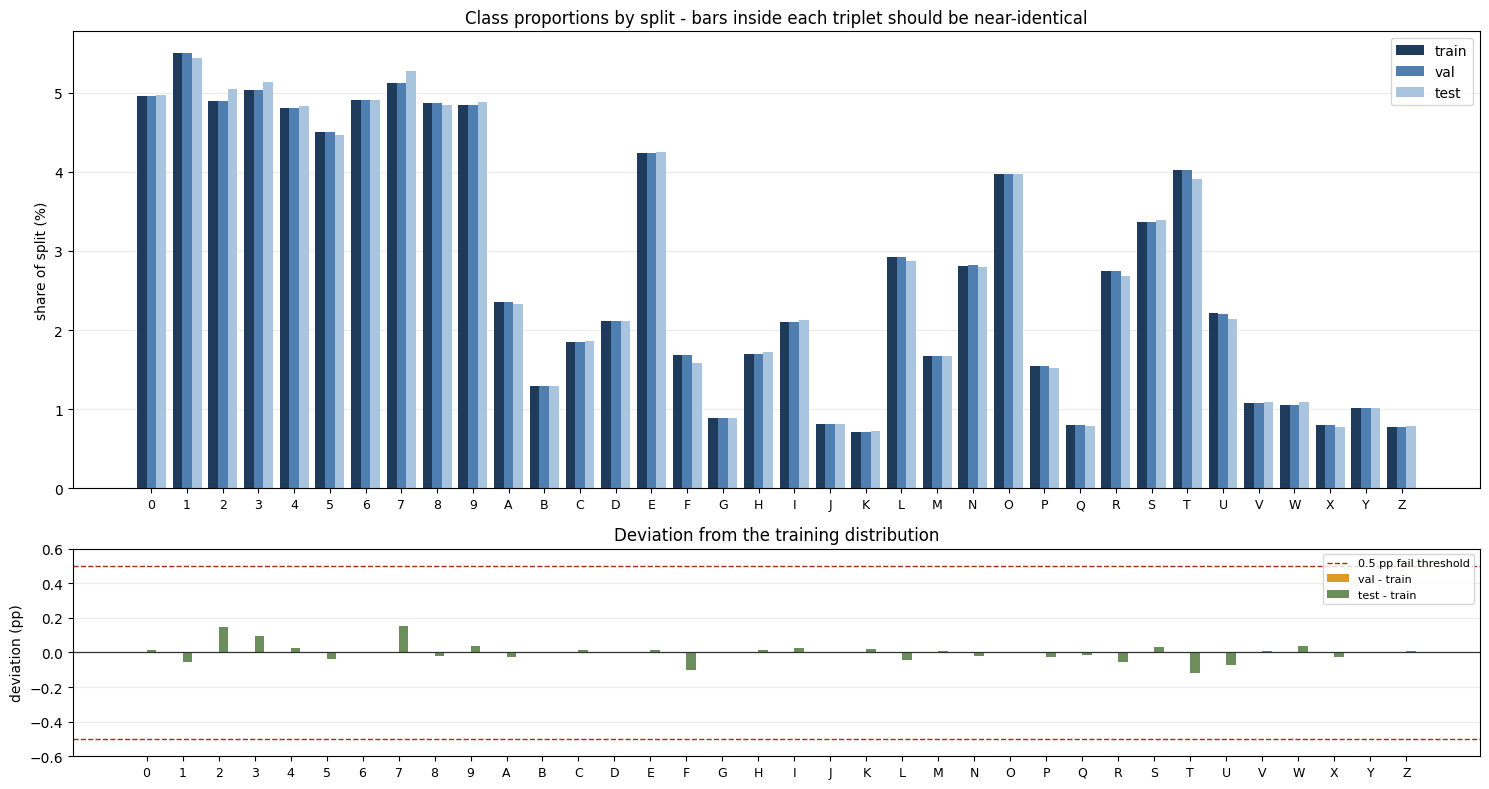

val  vs train: max |drift| = 0.003 pp
test vs train: max |drift| = 0.154 pp

Largest deviations:
   train    val   test  val-train (pp)  test-train (pp)
N 0.0282 0.0282 0.0279          0.0025          -0.0223
R 0.0275 0.0275 0.0269          0.0025          -0.0575
I 0.0210 0.0210 0.0213          0.0025           0.0246
G 0.0089 0.0089 0.0089          0.0025           0.0033
Q 0.0080 0.0080 0.0079         -0.0025          -0.0142


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8),
                               gridspec_kw={"height_ratios": [2.2, 1]})

# --- top: share of each class, three bars per character ---------------------
x = np.arange(len(prop_table)); w = 0.27
for k, (col, colr) in enumerate(zip(["train", "val", "test"],
                                    ["#1F3B5C", "#4E7FB0", "#A8C4DE"])):
    ax1.bar(x + (k - 1) * w, prop_table[col] * 100, w, label=col, color=colr)
ax1.set_xticks(x); ax1.set_xticklabels(prop_table.index, fontsize=9)
ax1.set_ylabel("share of split (%)")
ax1.set_title("Class proportions by split - bars inside each triplet should be near-identical")
ax1.legend(); ax1.grid(alpha=.25, axis="y"); ax1.set_axisbelow(True)

# --- bottom: the residual, which is what actually matters -------------------
ax2.axhline(0, color="#333", lw=.9)
ax2.axhline(0.5, color="#A3301C", ls="--", lw=1, label="0.5 pp fail threshold")
ax2.axhline(-0.5, color="#A3301C", ls="--", lw=1)
ax2.bar(x - w/2, prop_table["val-train (pp)"],  w, label="val - train",  color="#DB9B26")
ax2.bar(x + w/2, prop_table["test-train (pp)"], w, label="test - train", color="#6B8E5A")
ax2.set_xticks(x); ax2.set_xticklabels(prop_table.index, fontsize=9)
ax2.set_ylabel("deviation (pp)")
ax2.set_title("Deviation from the training distribution")
lim = max(0.6, prop_table[["val-train (pp)", "test-train (pp)"]].abs().max().max() * 1.4)
ax2.set_ylim(-lim, lim)
ax2.legend(fontsize=8); ax2.grid(alpha=.25, axis="y"); ax2.set_axisbelow(True)

plt.tight_layout(); plt.savefig("split_proportions.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"val  vs train: max |drift| = {prop_table['val-train (pp)'].abs().max():.3f} pp")
print(f"test vs train: max |drift| = {prop_table['test-train (pp)'].abs().max():.3f} pp")
print("\nLargest deviations:")
print(prop_table.reindex(prop_table["val-train (pp)"].abs()
                         .sort_values(ascending=False).index)
      .head(5)[["train", "val", "test", "val-train (pp)", "test-train (pp)"]].to_string())

Building pipeline

In [ ]:
# tf.data pipeline - normalization + camera-realistic augmentation
augment = keras.Sequential([
    layers.RandomRotation(0.05, fill_mode="constant", fill_value=0.0),
    layers.RandomTranslation(0.10, 0.10, fill_mode="constant", fill_value=0.0),
    layers.RandomZoom(0.10, fill_mode="constant", fill_value=0.0),
    layers.RandomContrast(0.25),
], name="augment")

def random_blur(x):
    k = tf.ones((3, 3, 1, 1), tf.float32) / 9.0
    blurred = tf.nn.depthwise_conv2d(x, k, strides=[1, 1, 1, 1], padding="SAME")
    m = tf.cast(tf.random.uniform((tf.shape(x)[0], 1, 1, 1)) < 0.30, tf.float32)
    return m * blurred + (1.0 - m) * x

def make_ds(X, y, training, batch=None, aug=True):
    batch = batch or CFG["batch_size"]
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    # normalize() is the single definition of uint8 -> float32 [0,1]
    ds = ds.map(lambda a, b: (normalize(a), b), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(20_000, seed=SEED).batch(batch)
        if aug:
            ds = ds.map(lambda a, b: (augment(a, training=True), b),
                        num_parallel_calls=tf.data.AUTOTUNE)
            ds = ds.map(lambda a, b: (random_blur(a), b),
                        num_parallel_calls=tf.data.AUTOTUNE)
            ds = ds.map(lambda a, b: (tf.clip_by_value(
                            a + tf.random.normal(tf.shape(a), 0.0, 0.06), 0.0, 1.0), b),
                        num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.batch(batch)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_tr, y_tr, training=True)
val_ds   = make_ds(X_va, y_va, training=False)
test_ds  = make_ds(X_te, y_te, training=False)
print("pipelines built:", train_ds.element_spec)

pipelines built: (TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Input contract verification

normalize() rejects float input - double-normalisation is blocked
assert_input_contract() rejects a double-normalised batch
  resizing 64x64 -> 28x28
RGB 64x64  -> (4, 28, 28, 1)
  resizing 14x14 -> 28x28
gray 14x14 -> (2, 28, 28, 1)
flat 784   -> (3, 28, 28, 1)

verified training batch: {'name': 'first augmented training batch', 'shape': [256, 28, 28, 1], 'dtype': 'float32', 'min': 0.0, 'max': 1.0, 'mean': 0.19923}


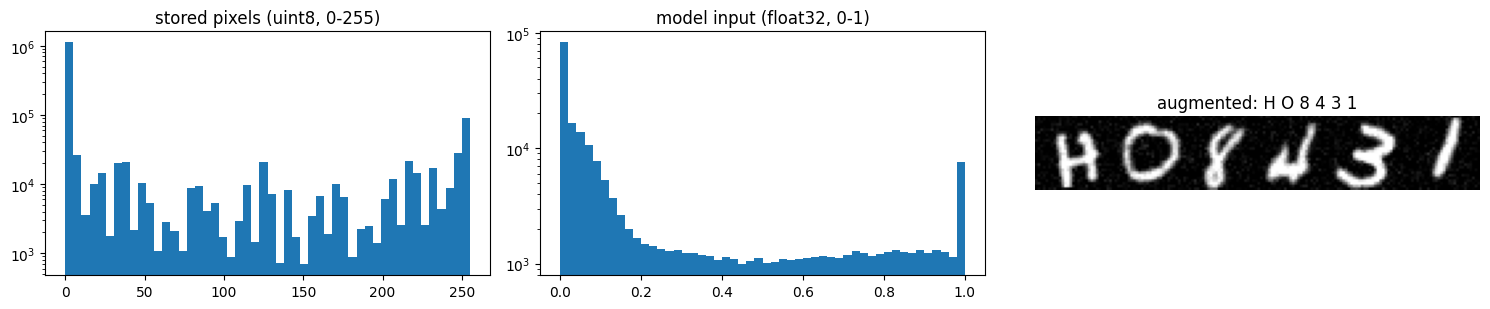

In [ ]:
_u8 = (np.random.rand(8, 28, 28, 1) * 255).astype(np.uint8)
assert_input_contract(normalize(_u8), "uint8 -> normalize")

for bad, label in [(normalize(_u8), "float32 already in [0,1]"),
                   (_u8.astype(np.float32), "float32 in [0,255]")]:
    try:
        normalize(bad); raise SystemExit(f"GUARD BROKEN: accepted {label}")
    except TypeError:
        pass
print("normalize() rejects float input - double-normalisation is blocked")

try:
    assert_input_contract(normalize(_u8) / 255.0, "double-normalised")
    raise SystemExit("GUARD BROKEN: accepted a double-normalised batch")
except AssertionError:
    print("assert_input_contract() rejects a double-normalised batch")

# resize path - the ticket says "resize to 28x28", so prove it resizes
print("RGB 64x64  ->", to_canonical_uint8((np.random.rand(4,64,64,3)*255).astype(np.uint8)).shape)
print("gray 14x14 ->", to_canonical_uint8((np.random.rand(2,14,14)*255).astype(np.uint8)).shape)
print("flat 784   ->", to_canonical_uint8(np.zeros((3, 784), np.uint8)).shape)

xb, yb = next(iter(train_ds))
stats = assert_input_contract(xb, "first augmented training batch")
print("\nverified training batch:", stats)
PROVENANCE["input_spec"] = INPUT_SPEC
PROVENANCE["input_contract_verified"] = stats

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(X_tr[:2000].ravel(), bins=50); ax[0].set_yscale("log")
ax[0].set_title("stored pixels (uint8, 0-255)")
ax[1].hist(xb.numpy().ravel(), bins=50); ax[1].set_yscale("log")
ax[1].set_title("model input (float32, 0-1)")
ax[2].imshow(np.hstack([xb[i].numpy().squeeze() for i in range(6)]), cmap="gray")
ax[2].set_title("augmented: " + " ".join(IDX2CHAR[int(yb[i])] for i in range(6)))
ax[2].axis("off")
plt.tight_layout(); plt.savefig("input_contract.png", dpi=140, bbox_inches="tight"); plt.show()

Sign off

In [ ]:
s = PROVENANCE["input_contract_verified"]
lines = ["# Image normalization - acceptance record", "",
    f"Generated {datetime.datetime.utcnow().isoformat(timespec='seconds')}Z", "",
    f"- **[{'PASS' if s['shape'][1:] == [28,28,1] else 'FAIL'}]** Resize to 28x28 grayscale",
    f"  - to_canonical_uint8() accepts 784-flat, (N,H,W), 1- or 3-channel; INTER_AREA down, INTER_CUBIC up",
    f"  - verified batch shape: {s['shape']}",
    f"- **[{'PASS' if s['dtype']=='float32' and 0 <= s['min'] and s['max'] <= 1 else 'FAIL'}]** Scale pixel values to 0 to 1",
    f"  - normalize() is the only division by 255 in the notebook; rejects float input",
    f"  - verified batch: dtype {s['dtype']}, range [{s['min']}, {s['max']}], mean {s['mean']}",
    f"- **[{'PASS' if PROVENANCE.get('orientation_verified') else 'FAIL'}]** Verify orientation",
    f"  - transpose applied: train {PROVENANCE['train']['transpose_applied']}, test {PROVENANCE['test']['transpose_applied']} (auto-detected, guard-enforced)",
    f"  - full evidence in acceptance_record.md",
    "", "## Input spec", "", f"```\n{json.dumps(INPUT_SPEC, indent=2)}\n```"]
open("normalization_acceptance_record.md", "w").write("\n".join(lines))
print("\n".join(lines))

from google.colab import files
files.download("normalization_acceptance_record.md")
files.download("input_contract.png")

# Image normalization - acceptance record

Generated 2026-08-14T18:26:59Z

- **[PASS]** Resize to 28x28 grayscale
  - to_canonical_uint8() accepts 784-flat, (N,H,W), 1- or 3-channel; INTER_AREA down, INTER_CUBIC up
  - verified batch shape: [256, 28, 28, 1]
- **[PASS]** Scale pixel values to 0 to 1
  - normalize() is the only division by 255 in the notebook; rejects float input
  - verified batch: dtype float32, range [0.0, 1.0], mean 0.19923
- **[PASS]** Verify orientation
  - transpose applied: train True, test True (auto-detected, guard-enforced)
  - full evidence in acceptance_record.md

## Input spec

```
{
  "height": 28,
  "width": 28,
  "channels": 1,
  "dtype": "float32",
  "vmin": 0.0,
  "vmax": 1.0,
  "storage_dtype": "uint8"
}
```


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#The Spike

**Riskiest assumption:** *a model trained on handwritten EMNIST characters will read
printed plate typefaces.*

In [ ]:
# SPIKE — does a handwriting-trained model read printed characters?
import cv2, glob as _glob
from PIL import Image, ImageDraw, ImageFont

t_spike = time.time()

# --- a deliberately small, fast model: this is a throwaway experiment --------
spike = keras.Sequential([
    layers.Input((28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Flatten(), layers.Dense(128, activation="relu"),
    layers.Dense(CFG["n_classes"], activation="softmax"),
], name="spike_cnn")
spike.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# 40k samples, 2 epochs, no augmentation - just enough to be informative
spike_ds = make_ds(X_tr[:40_000], y_tr[:40_000], training=True, aug=False)
spike.fit(spike_ds, epochs=2, verbose=1)

hand_acc = spike.evaluate(test_ds, verbose=0)[1]
print(f"\nheld-out HANDWRITTEN accuracy: {hand_acc:.3f}")

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6151 - loss: 1.3710
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8048 - loss: 0.6001

held-out HANDWRITTEN accuracy: 0.816


In [ ]:
# --- render printed characters in the fonts available on this machine -------
FONTS = [f for f in _glob.glob("/usr/share/fonts/**/*.ttf", recursive=True)
         if not any(b in f.lower() for b in
                    ("emoji","symbol","music","kacst","lohit","samyak","sinhala","japanese"))]
print(f"{len(FONTS)} usable fonts")

def render_glyph(ch, font_path, size=64):
    """Draw one character white-on-black, cropped to its ink."""
    img = Image.new("L", (size, size), 0)
    d = ImageDraw.Draw(img)
    try:
        f = ImageFont.truetype(font_path, int(size * 0.7))
    except Exception:
        return None
    b = d.textbbox((0, 0), ch, font=f)
    if b[2]-b[0] < 3 or b[3]-b[1] < 3:
        return None
    d.text(((size-(b[2]-b[0]))//2 - b[0], (size-(b[3]-b[1]))//2 - b[1]), ch, fill=255, font=f)
    return np.array(img)

def to_mnist_format(glyph):
    """Match EMNIST preprocessing: 20px longest side, centred by centre of mass
    in a 28x28 field. Training and inference MUST use the same recipe."""
    g = cv2.threshold(glyph, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    ys, xs = np.where(g > 0)
    if len(xs) == 0:
        return np.zeros((28, 28), np.uint8)
    g = g[ys.min():ys.max()+1, xs.min():xs.max()+1]
    h, w = g.shape
    s = 20.0 / max(h, w)
    g = cv2.resize(g, (max(1,int(round(w*s))), max(1,int(round(h*s)))),
                   interpolation=cv2.INTER_AREA)
    canvas = np.zeros((28, 28), np.uint8)
    h, w = g.shape
    canvas[(28-h)//2:(28-h)//2+h, (28-w)//2:(28-w)//2+w] = g
    m = cv2.moments(canvas)
    if m["m00"] > 0:
        dx, dy = 14 - m["m10"]/m["m00"], 14 - m["m01"]/m["m00"]
        canvas = cv2.warpAffine(canvas, np.float32([[1,0,dx],[0,1,dy]]), (28,28))
    return canvas

Xp, yp = [], []
for k, ch in enumerate(CHARS):
    for fp in FONTS[:25]:
        g = render_glyph(ch, fp)
        if g is not None:
            Xp.append(to_mnist_format(g)); yp.append(k)
Xp = np.array(Xp)[..., None]; yp = np.array(yp, np.int32)
print(f"printed test set: {Xp.shape}")

print_acc = spike.evaluate(make_ds(Xp, yp, training=False), verbose=0)[1]

print("\n" + "="*60)
print("SPIKE RESULT")
print("="*60)
print(f"  handwritten (held-out EMNIST) : {hand_acc:.3f}")
print(f"  printed (rendered fonts)      : {print_acc:.3f}")
print(f"  DOMAIN GAP                    : {hand_acc - print_acc:+.3f}")
print(f"  relative drop                 : {(1 - print_acc/max(hand_acc,1e-9))*100:.0f}%")
print("="*60)
print(f"spike wall time: {(time.time()-t_spike)/60:.1f} min")

SPIKE = dict(handwritten_acc=round(float(hand_acc), 4),
             printed_acc=round(float(print_acc), 4),
             gap=round(float(hand_acc - print_acc), 4),
             n_fonts=len(FONTS[:25]), n_printed=int(len(Xp)),
             epochs=2, n_train=40_000)
PROVENANCE["spike"] = SPIKE

17 usable fonts
printed test set: (612, 28, 28, 1)

SPIKE RESULT
  handwritten (held-out EMNIST) : 0.816
  printed (rendered fonts)      : 0.623
  DOMAIN GAP                    : +0.193
  relative drop                 : 24%
spike wall time: 0.4 min


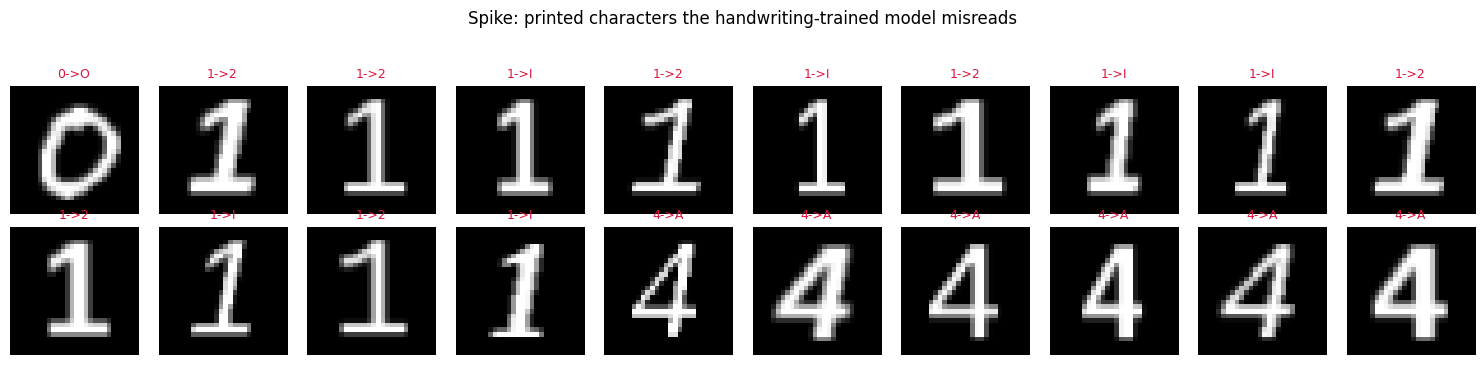

Worst printed characters:
char
M   0.0000
Q   0.0000
G   0.0000
K   0.0588
6   0.1176
4   0.1765
9   0.1765
W   0.1765
D   0.2353
I   0.2353


In [ ]:
# --- what does it actually get wrong on printed input? ----------------------
pp = spike.predict(normalize(Xp.astype(np.uint8)), verbose=0)
pred_p = pp.argmax(1)
wrong = np.where(pred_p != yp)[0]

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for ax, i in zip(axes.ravel(), wrong[:20]):
    ax.imshow(Xp[i].squeeze(), cmap="gray")
    ax.set_title(f"{IDX2CHAR[yp[i]]}->{IDX2CHAR[pred_p[i]]}", fontsize=9, color="crimson")
    ax.axis("off")
plt.suptitle("Spike: printed characters the handwriting-trained model misreads", y=1.06)
plt.tight_layout(); plt.savefig("spike_failures.png", dpi=140, bbox_inches="tight"); plt.show()

per_class = pd.DataFrame({"char": [IDX2CHAR[k] for k in yp], "ok": pred_p == yp}) \
              .groupby("char").ok.mean().sort_values()
print("Worst printed characters:")
print(per_class.head(10).to_string())

### Spike conclusion — what changed in the plan

The spike also produced two artefacts we now depend on: `render_glyph()` and
`to_mnist_format()`. The second encodes the **same** 20px/28px
centre-of-mass recipe EMNIST uses, and the segmentation stage below calls it, so training and inference preprocessing cannot drift apart.

#Epic 1: The character classifier

## 2.1 Class imbalance

ByClass preserves natural frequency: digits dominate, and letter frequency follows English
text. Plates do not follow English text, so this is a real mismatch. We measure it, then
correct with class weights rather than resampling (cheaper, and keeps every sample).

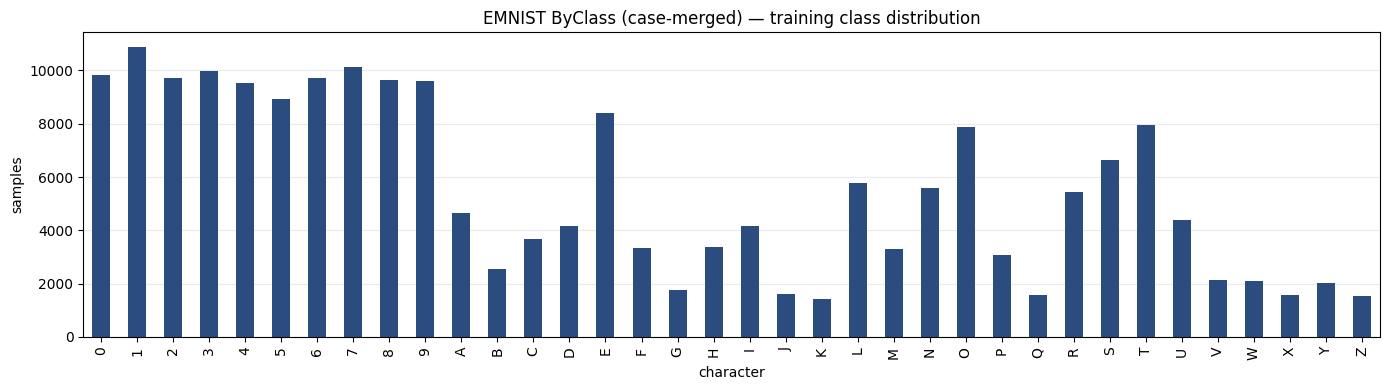

Most common : 1 (10,886)
Rarest      : K (1,407)
Imbalance   : 7.7x -> class weights needed

Rarest ten (these will be the weak classes in the confusion matrix):
K    1407
Z    1539
X    1587
Q    1589
J    1606
G    1759
Y    2016
W    2097
V    2141
B    2563

Heaviest class weights:
  K  x3.91
  Z  x3.57
  X  x3.47
  Q  x3.46
  J  x3.42
  G  x3.13


In [ ]:
counts = pd.Series(y_tr).value_counts().sort_index()
counts.index = [IDX2CHAR[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(14, 4))
counts.plot(kind="bar", ax=ax, color="#2B4C7E")
ax.set_title("EMNIST ByClass (case-merged) — training class distribution")
ax.set_xlabel("character"); ax.set_ylabel("samples"); ax.grid(alpha=.25, axis="y")
ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("class_distribution.png", dpi=140, bbox_inches="tight"); plt.show()

imb = counts.max() / counts.min()
print(f"Most common : {counts.idxmax()} ({counts.max():,})")
print(f"Rarest      : {counts.idxmin()} ({counts.min():,})")
print(f"Imbalance   : {imb:.1f}x -> {'class weights needed' if imb > 3 else 'roughly balanced'}")
print("\nRarest ten (these will be the weak classes in the confusion matrix):")
print(counts.sort_values().head(10).to_string())

from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(CFG["n_classes"]), y=y_tr)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("\nHeaviest class weights:")
for i, w in sorted(class_weight.items(), key=lambda kv: -kv[1])[:6]:
    print(f"  {IDX2CHAR[i]}  x{w:.2f}")

## 2.2 Baseline vs CNN

Two models so the report has a comparison rather than an assertion. The MLP establishes the
floor; the CNN is the working model. If the CNN does not clearly beat the MLP, the extra
complexity is not earning its place.

In [ ]:
# --- baseline: flatten + dense, no spatial structure ------------------------
mlp = keras.Sequential([
    layers.Input((28, 28, 1)),
    layers.Flatten(),
    layers.Dense(512, activation="relu"), layers.Dropout(0.3),
    layers.Dense(256, activation="relu"), layers.Dropout(0.3),
    layers.Dense(CFG["n_classes"], activation="softmax"),
], name="baseline_mlp")
mlp.compile(optimizer=keras.optimizers.Adam(CFG["lr"]),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mlp = mlp.fit(train_ds, validation_data=val_ds, epochs=CFG["epochs_mlp"],
                   class_weight=class_weight, verbose=1)
mlp_test = mlp.evaluate(test_ds, verbose=0)[1]
print(f"\nBaseline MLP test accuracy: {mlp_test:.4f}")

Epoch 1/6
774/774 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.5124 - loss: 1.7043 - val_accuracy: 0.7803 - val_loss: 0.6584
Epoch 2/6
774/774 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6650 - loss: 1.0771 - val_accuracy: 0.8099 - val_loss: 0.5518
Epoch 3/6
774/774 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - accuracy: 0.7021 - loss: 0.9358 - val_accuracy: 0.8249 - val_loss: 0.5082
Epoch 4/6
774/774 ━━━━━━━━━━━━━━━━━━━━ 85s 58ms/step - accuracy: 0.7184 - loss: 0.8673 - val_accuracy: 0.8312 - val_loss: 0.4851
Epoch 5/6
774/774 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.7310 - loss: 0.8281 - val_accuracy: 0.8414 - val_loss: 0.4549
Epoch 6/6
774/774 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.7392 - loss: 0.7986 - val_accuracy: 0.8411 - val_loss: 0.4484

Baseline MLP test accuracy: 0.8406


In [ ]:
# --- the working model: 3 VGG-style blocks ----------------------------------
def build_cnn():
    inp = layers.Input((28, 28, 1)); x = inp
    for f in (32, 64, 128):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x); x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)
    return keras.Model(inp, layers.Dense(CFG["n_classes"], activation="softmax",
                                         name="probs")(x), name="plate_char_cnn")

cnn = build_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(CFG["lr"]),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()
print(f"\ntrainable parameters: {cnn.count_params():,}")

Model: "plate_char_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 592,964 (2.26 MB)

 Trainable params: 591,556 (2.26 MB)

 Non-trainable params: 1,408 (5.50 KB)


trainable parameters: 592,964


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                                      min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint("best_cnn.keras", monitor="val_accuracy",
                                    save_best_only=True, verbose=0),
]
t0 = time.time()
hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=CFG["epochs_cnn"],
                   class_weight=class_weight, callbacks=callbacks, verbose=1)
print(f"\ntrained in {(time.time()-t0)/60:.1f} min")

Epoch 1/18
774/774 ━━━━━━━━━━━━━━━━━━━━ 68s 70ms/step - accuracy: 0.6642 - loss: 1.0948 - val_accuracy: 0.8665 - val_loss: 0.3663 - learning_rate: 0.0010
Epoch 2/18
774/774 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.8106 - loss: 0.5249 - val_accuracy: 0.8794 - val_loss: 0.3301 - learning_rate: 0.0010
Epoch 3/18
774/774 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.8323 - loss: 0.4540 - val_accuracy: 0.8821 - val_loss: 0.3196 - learning_rate: 0.0010
Epoch 4/18
774/774 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.8413 - loss: 0.4212 - val_accuracy: 0.8878 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 5/18
774/774 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.8489 - loss: 0.3963 - val_accuracy: 0.8869 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 6/18
773/774 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8527 - loss: 0.3830
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
774/774 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.8544 - los

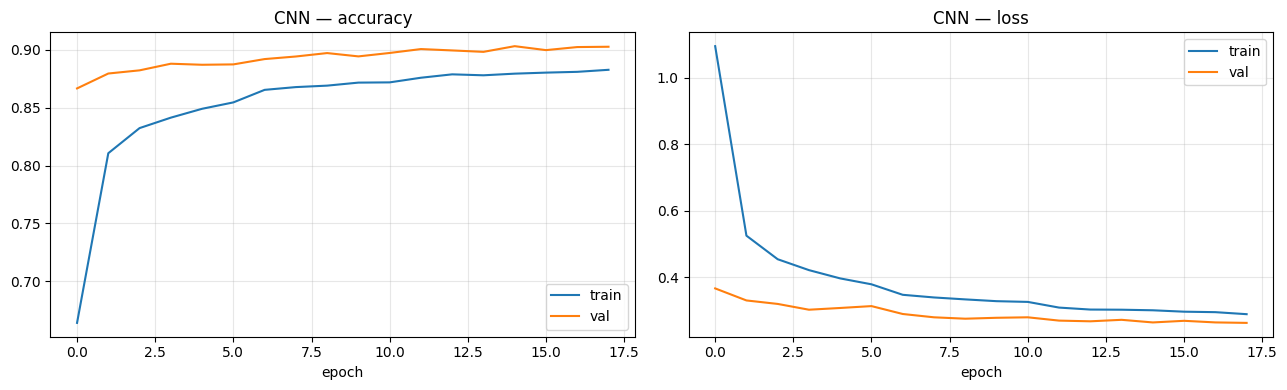

       model  test accuracy  parameters
Baseline MLP         0.8406      542500
         CNN         0.9013      592964

Note: validation accuracy above training accuracy is expected here —
augmentation and dropout are active on the training split only.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, (m, lbl) in enumerate([("accuracy", "accuracy"), ("loss", "loss")]):
    ax[k].plot(hist_cnn.history[m], label="train")
    ax[k].plot(hist_cnn.history["val_"+m], label="val")
    ax[k].set_title(f"CNN — {lbl}"); ax[k].set_xlabel("epoch")
    ax[k].legend(); ax[k].grid(alpha=.3)
plt.tight_layout(); plt.savefig("training_curves.png", dpi=140, bbox_inches="tight"); plt.show()

cnn_test = cnn.evaluate(test_ds, verbose=0)[1]
print(pd.DataFrame({"model": ["Baseline MLP", "CNN"],
                    "test accuracy": [mlp_test, cnn_test],
                    "parameters": [mlp.count_params(), cnn.count_params()]}).to_string(index=False))
print("\nNote: validation accuracy above training accuracy is expected here —")
print("augmentation and dropout are active on the training split only.")

## 2.3 Character-level error analysis

Aggregate accuracy is the least useful number here. What matters operationally is *which*
characters fail and *which pairs* get swapped, because a `0`/`O` confusion bills the wrong
customer.

              precision    recall  f1-score   support

           0      0.674     0.780     0.723      2980
           1      0.691     0.799     0.741      3265
           2      0.986     0.900     0.941      3027
           3      0.995     0.994     0.995      3079
           4      0.989     0.955     0.972      2898
           5      0.955     0.936     0.946      2677
           6      0.990     0.954     0.972      2943
           7      0.992     0.993     0.993      3166
           8      0.990     0.972     0.981      2906
           9      0.950     0.949     0.950      2933
           A      0.949     0.965     0.957      1396
           B      0.859     0.968     0.910       774
           C      0.967     0.969     0.968      1120
           D      0.916     0.975     0.944      1270
           E      0.986     0.987     0.986      2550
           F      0.971     0.976     0.973       949
           G      0.732     0.852     0.788       535
           H      0.945    

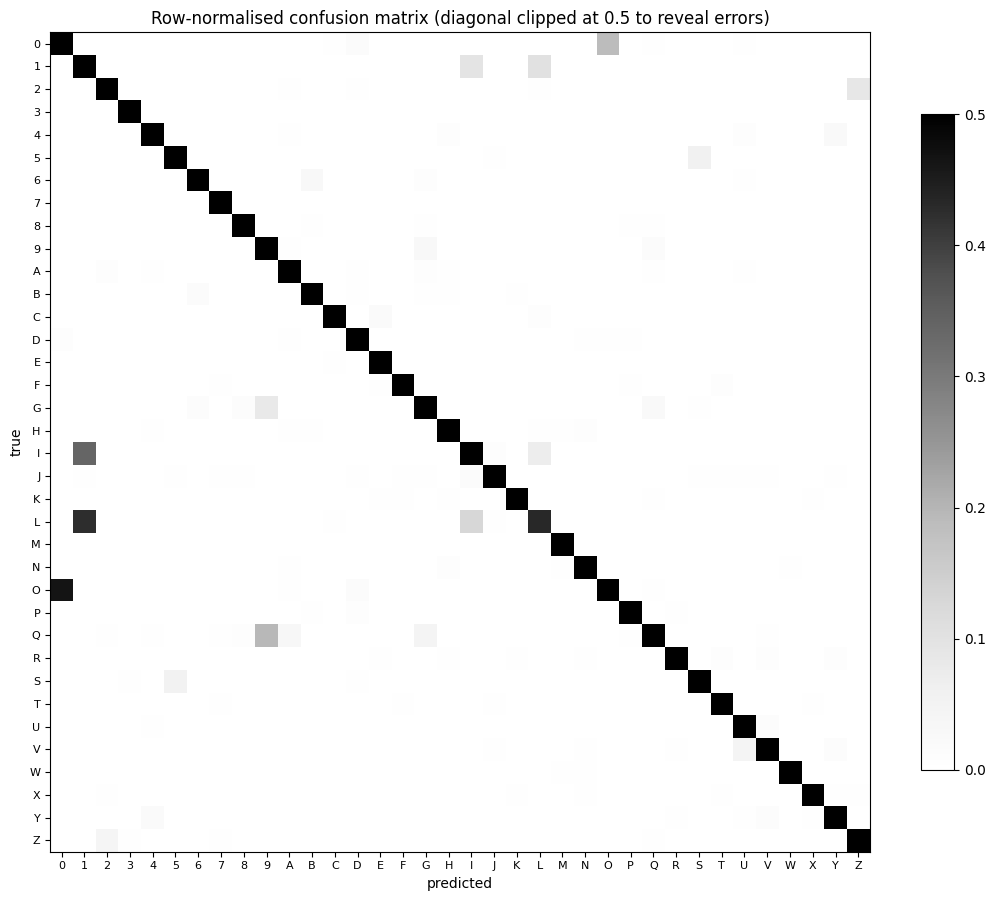

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

probs_te = cnn.predict(test_ds, verbose=0)
pred_te = probs_te.argmax(1)
print(classification_report(y_te, pred_te, target_names=list(CHARS), digits=3))
print(f"Macro F1: {f1_score(y_te, pred_te, average='macro'):.4f}")

cm = confusion_matrix(y_te, pred_te, labels=np.arange(CFG["n_classes"]))
cm_norm = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap="Greys", vmin=0, vmax=0.5)
ax.set_xticks(range(36)); ax.set_xticklabels(list(CHARS), fontsize=8)
ax.set_yticks(range(36)); ax.set_yticklabels(list(CHARS), fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Row-normalised confusion matrix (diagonal clipped at 0.5 to reveal errors)")
plt.colorbar(im, ax=ax, shrink=.8)
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=140, bbox_inches="tight"); plt.show()

Top 15 confusion pairs:

true predicted  error_rate  n_errors
   O         0      0.4648      1108
   L         1      0.4241       732
   I         1      0.3370       430
   Q         9      0.1945        92
   0         O      0.1879       560
   L         I      0.1275       220
   1         L      0.1017       332
   1         I      0.0946       309
   2         Z      0.0849       257
   G         9      0.0804        43
   I         L      0.0713        91
   5         S      0.0553       148
   S         5      0.0526       107
   Q         G      0.0465        22
   V         U      0.0445        29

Prior confusable pairs, confirmed at >1% error rate:
  0 <-> O: YES
  1 <-> I: YES
  5 <-> S: YES
  8 <-> B: no
  2 <-> Z: YES
  6 <-> G: YES
  7 <-> T: no
  4 <-> A: no
  D <-> O: YES
  U <-> V: YES


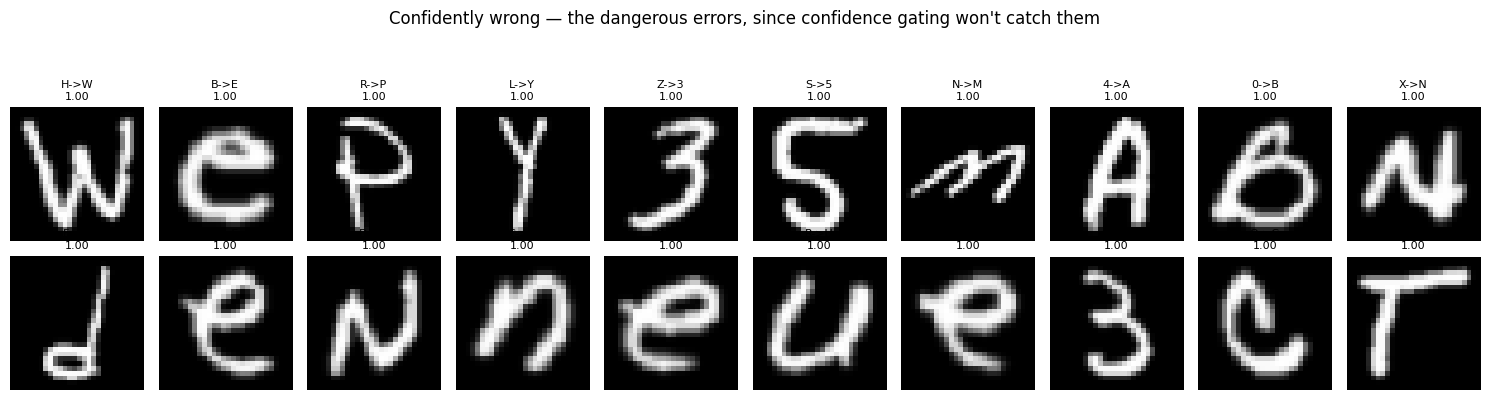

In [ ]:
off = cm_norm.copy(); np.fill_diagonal(off, 0)
pairs = [(IDX2CHAR[i], IDX2CHAR[j], off[i, j], int(cm[i, j]))
         for i in range(36) for j in range(36) if off[i, j] > 0]
top = pd.DataFrame(sorted(pairs, key=lambda p: -p[2])[:15],
                   columns=["true", "predicted", "error_rate", "n_errors"])
print("Top 15 confusion pairs:\n"); print(top.to_string(index=False))

print("\nPrior confusable pairs, confirmed at >1% error rate:")
found = {(a, b) for a, b, r, _ in pairs if r > 0.01}
for a, b in CONFUSABLE_PAIRS:
    hit = (a, b) in found or (b, a) in found
    print(f"  {a} <-> {b}: {'YES' if hit else 'no'}")

wrong = np.where(pred_te != y_te)[0]
worst = wrong[np.argsort(-probs_te[wrong].max(1))][:20]   # confidently wrong
fig, axes = plt.subplots(2, 10, figsize=(15, 3.6))
for ax, i in zip(axes.ravel(), worst):
    ax.imshow(X_te[i].squeeze(), cmap="gray")
    ax.set_title(f"{IDX2CHAR[y_te[i]]}->{IDX2CHAR[pred_te[i]]}\n{probs_te[i].max():.2f}", fontsize=8)
    ax.axis("off")
plt.suptitle("Confidently wrong — the dangerous errors, since confidence gating won't catch them", y=1.10)
plt.tight_layout(); plt.savefig("confident_errors.png", dpi=140, bbox_inches="tight"); plt.show()

# Epic 2 — Segmentation: plate image in, character crops out

We have no licensed plate corpus (§11: plate numbers are personal data), so we build our own
test set by rendering plates programmatically. We control the text, so ground truth is free.

**Scope statement:** we are **not** attempting plate localization. We assume a cropped plate.
Detecting the plate within a road scene is named in §Scope as out of scope for Week 2.

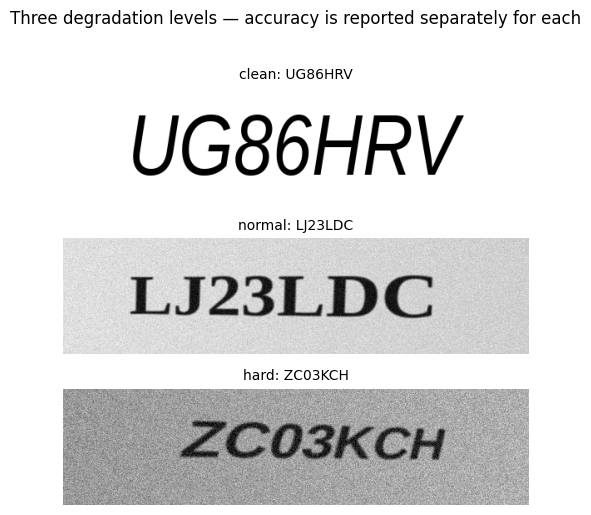

In [ ]:
# Synthetic plate generator — our test set with known ground truth

def random_plate_text(length=None):
    length = length or CFG["plate_len"]
    # I, O, Q omitted: many jurisdictions never issue them, precisely because
    # they are confusable with 1, 0 and O.
    return "".join(random.choice("ABCDEFGHJKLMNPRSTUVWXYZ" if i < 2 or i > 3
                                 else "0123456789") for i in range(length))

def render_plate(text, font_path=None, W=560, H=140):
    font_path = font_path or random.choice(FONTS)
    img = Image.new("L", (W, H), color=random.randint(200, 255))    # light plate
    draw = ImageDraw.Draw(img)
    size = int(H * random.uniform(0.62, 0.76))
    try:    font = ImageFont.truetype(font_path, size)
    except Exception: font = ImageFont.truetype(FONTS[0], size)
    b = draw.textbbox((0, 0), text, font=font)
    draw.text(((W-(b[2]-b[0]))//2 - b[0], (H-(b[3]-b[1]))//2 - b[1]),
              text, fill=random.randint(0, 55), font=font)          # dark glyphs
    return np.array(img)

def degrade(img, level="normal"):
    """Camera-realistic degradation. 'level' lets us report accuracy BY CONDITION,
    which §5 requires: every number must state the image quality it was measured under."""
    cfg = dict(clean=(0.0, 0, (1.0,1.0), 0),
               normal=(0.045, 3, (0.75,1.0), 8),
               hard=(0.085, 5, (0.55,1.0), 18))[level]
    skew, blur_k, light, noise = cfg
    h, w = img.shape
    if skew > 0:
        d = w * skew
        src = np.float32([[0,0],[w,0],[w,h],[0,h]])
        dst = np.float32([[random.uniform(0,d), random.uniform(0,d)],
                          [w-random.uniform(0,d), random.uniform(0,d)],
                          [w-random.uniform(0,d), h-random.uniform(0,d)],
                          [random.uniform(0,d), h-random.uniform(0,d)]])
        img = cv2.warpPerspective(img, cv2.getPerspectiveTransform(src, dst), (w, h),
                                  borderValue=int(img[0, 0]))
    if blur_k >= 3 and random.random() < 0.7:
        img = cv2.GaussianBlur(img, (blur_k, blur_k), 0)
    grad = np.linspace(random.uniform(*light), random.uniform(*light), w)[None, :]
    img = np.clip(img.astype(np.float32) * grad, 0, 255)
    if noise: img = np.clip(img + np.random.normal(0, noise, img.shape), 0, 255)
    return img.astype(np.uint8)

def make_plate(text=None, level="normal"):
    text = text or random_plate_text()
    return degrade(render_plate(text), level), text

fig, axes = plt.subplots(3, 1, figsize=(9, 5))
for ax, lvl in zip(axes, ["clean", "normal", "hard"]):
    im, txt = make_plate(level=lvl)
    ax.imshow(im, cmap="gray"); ax.set_title(f"{lvl}: {txt}", fontsize=10); ax.axis("off")
plt.suptitle("Three degradation levels — accuracy is reported separately for each", y=1.02)
plt.tight_layout(); plt.savefig("plate_conditions.png", dpi=140, bbox_inches="tight"); plt.show()

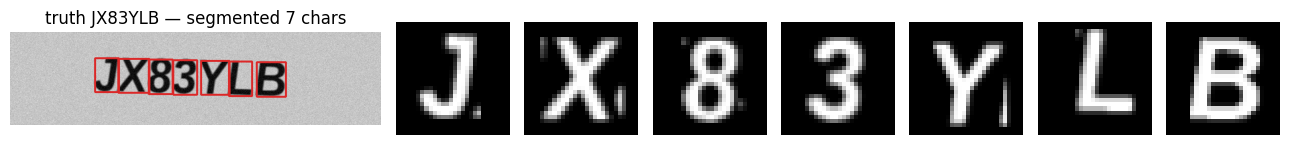

In [ ]:
# Character segmentation — connected components (v2: handles merged glyphs)

def segment_plate_v1(plate_img, expected=None):
    """Original version, kept only for the before/after comparison below.

    Its `ch/cw < 0.8` filter discards any contour flatter than a single
    upright glyph - which is exactly what a merged pair of touching
    characters looks like. That is the bug v2 fixes.
    """
    h, w = plate_img.shape
    blur = cv2.GaussianBlur(plate_img, (3, 3), 0)
    bin_ = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    bin_ = cv2.morphologyEx(bin_, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))
    cnts, _ = cv2.findContours(bin_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x, y, cw, ch = cv2.boundingRect(c)
        if ch < 0.35*h or ch > 0.98*h:  continue
        if cw > 0.30*w or cw < 0.008*w: continue
        if ch / max(cw, 1) < 0.8:       continue
        boxes.append((x, y, cw, ch))
    boxes.sort(key=lambda b: b[0])
    if expected and len(boxes) > expected:
        boxes = sorted(sorted(boxes, key=lambda b: -b[3])[:expected], key=lambda b: b[0])
    pad = 2
    chars = []
    for x, y, cw, ch in boxes:
        crop = plate_img[max(0,y-pad):min(h,y+ch+pad), max(0,x-pad):min(w,x+cw+pad)]
        chars.append(to_mnist_format(255 - crop))
    return chars, boxes


def segment_plate(plate_img, expected=None):
    """Binarise, find contours, SPLIT merged glyphs, sort left-to-right.

    Sprint 2 measured only 82.5% segmentation success on CLEAN plates with
    zero degradation - the dominant failure mode was under-segmentation:
    touching or kerned-together characters merging into one wide contour,
    which v1 discarded outright instead of splitting.

    Fix: collect candidates with a looser aspect-ratio bar (0.45 instead of
    0.8, so a merged pair is not thrown away before we get a chance at it),
    estimate a reference single-glyph width from the boxes that already look
    like one character, then recursively split any box much wider than that
    reference at the deepest valley in its vertical ink-projection profile -
    the standard column-projection approach to touching-character
    segmentation. A split only fires if the valley is meaningfully emptier
    than its immediate neighbourhood, which stops it triggering on a single
    wide glyph such as M or W.
    """
    h, w = plate_img.shape
    blur = cv2.GaussianBlur(plate_img, (3, 3), 0)
    bin_ = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    bin_ = cv2.morphologyEx(bin_, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))
    cnts, _ = cv2.findContours(bin_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    raw = []
    for c in cnts:
        x, y, cw, ch = cv2.boundingRect(c)
        if ch < 0.35*h or ch > 0.98*h:  continue   # too small / whole-frame noise
        if cw < 0.008*w:                continue   # specks
        if ch / max(cw, 1) < 0.45:      continue   # even a 2-glyph merge isn't this flat
        raw.append((x, y, cw, ch))
    raw.sort(key=lambda b: b[0])
    if not raw:
        return [], []

    # Reference single-glyph width, from boxes that already look like ONE
    # character (v1's original, stricter bar - kept here just to define "normal").
    single = [b for b in raw if b[3] / max(b[2], 1) >= 0.8]
    ref_w = float(np.median([b[2] for b in single])) if single \
        else float(np.median([b[2] for b in raw]))

    def split_wide(x, y, cw, ch, depth=0):
        n_glyphs = round(cw / ref_w) if ref_w > 0 else 1
        if depth > 3 or n_glyphs < 2:
            return [(x, y, cw, ch)]
        region = bin_[y:y+ch, x:x+cw]
        col_ink = region.sum(axis=0).astype(np.float32)
        margin = max(2, int(cw * 0.15))
        if cw - 2*margin < 3:
            return [(x, y, cw, ch)]
        window = col_ink[margin: cw - margin]
        v_rel = int(np.argmin(window))
        valley = margin + v_rel
        neigh = np.concatenate([col_ink[max(0, valley-3):valley],
                                col_ink[valley+1:valley+4]])
        if len(neigh) == 0 or neigh.mean() <= 0 or col_ink[valley] > 0.6 * neigh.mean():
            return [(x, y, cw, ch)]           # no real gap - one wide glyph, don't split
        left, right = (x, y, valley, ch), (x+valley, y, cw-valley, ch)
        return split_wide(*left, depth+1) + split_wide(*right, depth+1)

    boxes = []
    for (x, y, cw, ch) in raw:
        if cw > 1.45 * ref_w and ref_w > 0:
            boxes.extend(split_wide(x, y, cw, ch))
        elif cw > 0.55 * w:                    # still absurd, no reliable ref - drop
            continue
        else:
            boxes.append((x, y, cw, ch))
    boxes.sort(key=lambda b: b[0])

    if expected and len(boxes) > expected:      # still over-segmented -> keep tallest
        boxes = sorted(sorted(boxes, key=lambda b: -b[3])[:expected], key=lambda b: b[0])

    pad = 2
    chars = []
    for x, y, cw, ch in boxes:
        crop = plate_img[max(0,y-pad):min(h,y+ch+pad), max(0,x-pad):min(w,x+cw+pad)]
        # SAME recipe as training data - see the spike. This is the integration trap.
        chars.append(to_mnist_format(255 - crop))
    return chars, boxes


plate, truth = make_plate()
chars, boxes = segment_plate(plate, expected=CFG["plate_len"])
vis = cv2.cvtColor(plate, cv2.COLOR_GRAY2RGB)
for x, y, cw, ch in boxes:
    cv2.rectangle(vis, (x, y), (x+cw, y+ch), (220, 40, 40), 2)

fig = plt.figure(figsize=(13, 3.2))
ax1 = plt.subplot2grid((1, max(len(chars),1)+3), (0, 0), colspan=3)
ax1.imshow(vis); ax1.set_title(f"truth {truth} — segmented {len(chars)} chars"); ax1.axis("off")
for i, c in enumerate(chars):
    ax = plt.subplot2grid((1, len(chars)+3), (0, 3+i))
    ax.imshow(c, cmap="gray"); ax.axis("off")
plt.tight_layout(); plt.savefig("segmentation_demo.png", dpi=140, bbox_inches="tight"); plt.show()

Segmentation success rate, same 300 plates, same seed, both versions:

  v1 (no splitting)            segmentation success @ clean : 0.803   (char-count distribution: {3: 3, 4: 6, 5: 22, 6: 28, 7: 241})
  v2 (splits merged glyphs)    segmentation success @ clean : 0.947   (char-count distribution: {4: 3, 5: 3, 6: 10, 7: 284})

  v1 (no splitting)            segmentation success @ normal: 0.547   (char-count distribution: {0: 21, 1: 5, 2: 9, 3: 15, 4: 13, 5: 22, 6: 51, 7: 164})
  v2 (splits merged glyphs)    segmentation success @ normal: 0.740   (char-count distribution: {0: 18, 1: 8, 2: 3, 3: 7, 4: 12, 5: 15, 6: 15, 7: 222})

  v1 (no splitting)            segmentation success @ hard  : 0.093   (char-count distribution: {0: 188, 1: 20, 2: 19, 3: 10, 4: 8, 5: 12, 6: 15, 7: 28})
  v2 (splits merged glyphs)    segmentation success @ hard  : 0.137   (char-count distribution: {0: 158, 1: 32, 2: 31, 3: 8, 4: 10, 5: 7, 6: 13, 7: 41})

condition     v1     v2  improvement_pp
    clean 0.8033 

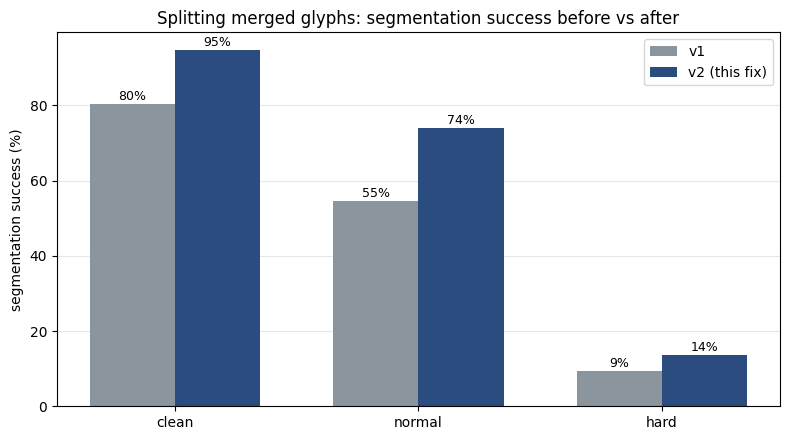


All evaluation cells below use segment_plate (v2) automatically -
nothing downstream needed to change, only its output is now stale. Re-run from here down.


In [ ]:
# ============================================================================
# v1 vs v2 — did splitting merged glyphs actually help?
# ============================================================================
def seg_success_rate(fn, n=300, level="clean", seed=SEED, tag=""):
    random.seed(seed); np.random.seed(seed)
    hits, counts = 0, []
    for _ in range(n):
        img, truth = make_plate(level=level)
        chars, _ = fn(img, expected=CFG["plate_len"])
        counts.append(len(chars))
        if len(chars) == len(truth):
            hits += 1
    rate = hits / n
    print(f"  {tag:<28} segmentation success @ {level:<6}: {rate:.3f}   "
         f"(char-count distribution: {pd.Series(counts).value_counts().sort_index().to_dict()})")
    return rate

print("Segmentation success rate, same 300 plates, same seed, both versions:\n")
rows = []
for level in ["clean", "normal", "hard"]:
    r1 = seg_success_rate(segment_plate_v1, level=level, tag="v1 (no splitting)")
    r2 = seg_success_rate(segment_plate,    level=level, tag="v2 (splits merged glyphs)")
    rows.append(dict(condition=level, v1=r1, v2=r2, improvement_pp=(r2-r1)*100))
    print()

improvement = pd.DataFrame(rows)
print(improvement.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(improvement)); w = 0.35
ax.bar(x - w/2, improvement.v1*100, w, label="v1", color="#8B959E")
ax.bar(x + w/2, improvement.v2*100, w, label="v2 (this fix)", color="#2B4C7E")
ax.set_xticks(x); ax.set_xticklabels(improvement.condition)
ax.set_ylabel("segmentation success (%)")
ax.set_title("Splitting merged glyphs: segmentation success before vs after")
ax.legend(); ax.grid(alpha=.3, axis="y"); ax.set_axisbelow(True)
for i, (a, b) in enumerate(zip(improvement.v1, improvement.v2)):
    ax.text(i-w/2, a*100+1, f"{a:.0%}", ha="center", fontsize=9)
    ax.text(i+w/2, b*100+1, f"{b:.0%}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("segmentation_v1_vs_v2.png", dpi=140, bbox_inches="tight"); plt.show()

print("\nAll evaluation cells below use segment_plate (v2) automatically -")
print("nothing downstream needed to change, only its output is now stale. Re-run from here down.")

> **Re-run required below this point.**

# Epic 3 — Integration: the first full plate read

**Errors compound.** A plate is only correct if *every* character is correct:

$$P(\text{plate correct}) \approx p^{L}$$

At 7 characters, a 95% character model reads only **70%** of plates. To reach 95% at the
plate level you need **99.3%** per character. This single fact drives the business case.

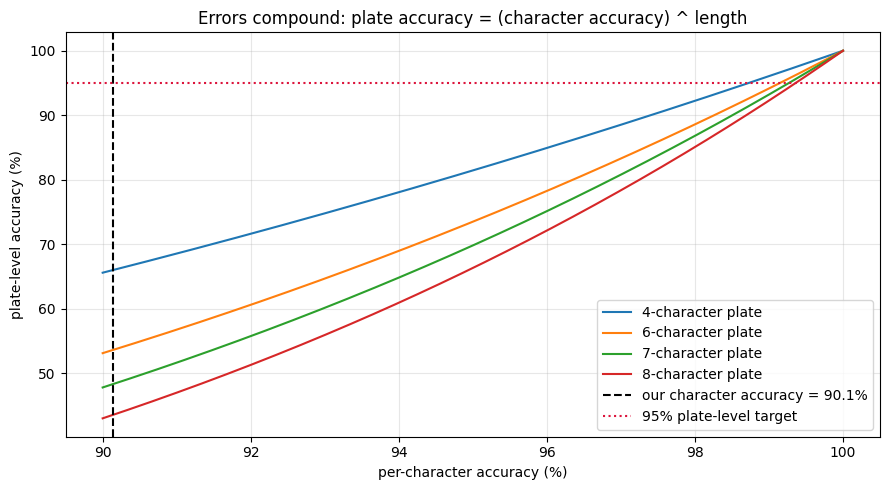

At p=0.9013, predicted plate accuracy = 0.4833
For 95% plate accuracy you need p = 0.9927


In [ ]:
p = np.linspace(0.90, 1.0, 300)
fig, ax = plt.subplots(figsize=(9, 5))
for L in (4, 6, 7, 8):
    ax.plot(p*100, p**L*100, label=f"{L}-character plate")
ax.axvline(cnn_test*100, ls="--", color="k", label=f"our character accuracy = {cnn_test*100:.1f}%")
ax.axhline(95, ls=":", color="crimson", label="95% plate-level target")
ax.set_xlabel("per-character accuracy (%)"); ax.set_ylabel("plate-level accuracy (%)")
ax.set_title("Errors compound: plate accuracy = (character accuracy) ^ length")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("error_compounding.png", dpi=140, bbox_inches="tight"); plt.show()

L = CFG["plate_len"]
print(f"At p={cnn_test:.4f}, predicted plate accuracy = {cnn_test**L:.4f}")
print(f"For 95% plate accuracy you need p = {0.95**(1/L):.4f}")

In [ ]:
# End-to-end read + evaluation BY CONDITION
def read_plate(plate_img, model, expected=CFG["plate_len"]):
    chars, boxes = segment_plate(plate_img, expected=expected)
    if not chars:
        return "", np.array([]), []
    batch = normalize(np.stack(chars)[..., None].astype(np.uint8))
    probs = model.predict(batch, verbose=0)
    return "".join(IDX2CHAR[i] for i in probs.argmax(1)), probs.max(1), chars

def evaluate_plates(model, n=CFG["n_eval_plates"], level="normal", seed=SEED, tag=""):
    random.seed(seed); np.random.seed(seed)
    rows = []
    for _ in range(n):
        img, truth = make_plate(level=level)
        pred, confs, _ = read_plate(img, model)
        seg_ok = len(pred) == len(truth)
        char_ok = sum(a == b for a, b in zip(pred, truth)) if seg_ok else 0
        rows.append(dict(truth=truth, pred=pred, seg_ok=seg_ok, plate_ok=(pred == truth),
                         char_acc=char_ok/len(truth),
                         min_conf=float(confs.min()) if len(confs) else 0.0))
    df = pd.DataFrame(rows)
    print(f"--- {tag or level} (n={n}) ---")
    print(f"  segmentation success : {df.seg_ok.mean():.3f}")
    print(f"  character accuracy   : {df.char_acc.mean():.3f}")
    print(f"  PLATE accuracy       : {df.plate_ok.mean():.3f}")
    return df

results = {}
for lvl in ["clean", "normal", "hard"]:
    results[lvl] = evaluate_plates(cnn, level=lvl)

summary = pd.DataFrame({
    "condition": ["clean", "normal", "hard"],
    "segmentation": [results[l].seg_ok.mean() for l in ["clean","normal","hard"]],
    "character acc": [results[l].char_acc.mean() for l in ["clean","normal","hard"]],
    "plate acc": [results[l].plate_ok.mean() for l in ["clean","normal","hard"]],
})
print("\n" + summary.to_string(index=False))
print(f"\nFor contrast, held-out EMNIST character accuracy was {cnn_test:.3f}.")
print("The gap between that and the printed-plate column is the domain gap the spike found.")

--- clean (n=400) ---
  segmentation success : 0.955
  character accuracy   : 0.843
  PLATE accuracy       : 0.502
--- normal (n=400) ---
  segmentation success : 0.730
  character accuracy   : 0.624
  PLATE accuracy       : 0.340
--- hard (n=400) ---
  segmentation success : 0.122
  character accuracy   : 0.109
  PLATE accuracy       : 0.055

condition  segmentation  character acc  plate acc
    clean        0.9550         0.8432     0.5025
   normal        0.7300         0.6239     0.3400
     hard        0.1225         0.1089     0.0550

For contrast, held-out EMNIST character accuracy was 0.901.
The gap between that and the printed-plate column is the domain gap the spike found.


### Deliberate failure

Force the hard condition and display cases
where the pipeline breaks, separating the two distinct causes.

of 400 hard plates:
  segmentation failures (wrong character count) : 351
  recognition failures  (right count, wrong text): 27

These are different bugs and would be fixed differently:
  segmentation -> better binarisation, or a CTC model that skips segmentation
  recognition  -> more/printed training data, domain adaptation


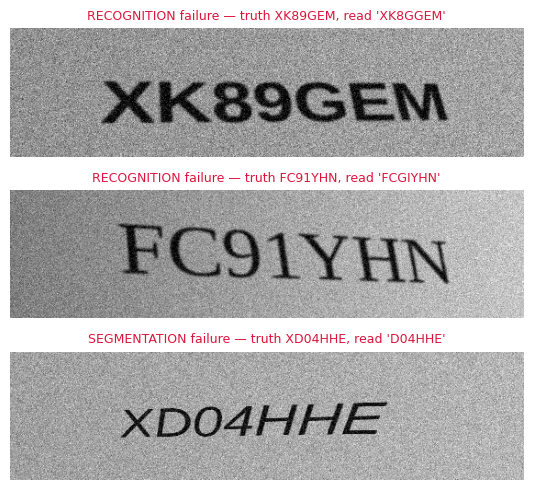

In [ ]:
df_hard = results["hard"]
seg_fail = df_hard[~df_hard.seg_ok]
rec_fail = df_hard[df_hard.seg_ok & ~df_hard.plate_ok]

print(f"of {len(df_hard)} hard plates:")
print(f"  segmentation failures (wrong character count) : {len(seg_fail)}")
print(f"  recognition failures  (right count, wrong text): {len(rec_fail)}")
print("\nThese are different bugs and would be fixed differently:")
print("  segmentation -> better binarisation, or a CTC model that skips segmentation")
print("  recognition  -> more/printed training data, domain adaptation")

random.seed(SEED); np.random.seed(SEED)
fig, axes = plt.subplots(3, 1, figsize=(9, 5))
shown = pd.concat([rec_fail.head(2), seg_fail.head(1)]) if len(seg_fail) else rec_fail.head(3)
for ax, (_, r) in zip(axes, shown.iterrows()):
    img, _ = make_plate(r.truth, level="hard")
    ax.imshow(img, cmap="gray"); ax.axis("off")
    kind = "SEGMENTATION" if not r.seg_ok else "RECOGNITION"
    ax.set_title(f"{kind} failure — truth {r.truth}, read '{r.pred}'", fontsize=9, color="crimson")
plt.tight_layout(); plt.savefig("failure_cases.png", dpi=140, bbox_inches="tight"); plt.show()

# Epic 4 — Measurement and the business case

## 4.1 Confidence gating — the automation dial

No production ANPR auto-accepts every read. It accepts above a confidence threshold and
routes the rest to a human. That gives two levers: **coverage** (share handled with no human)
and **precision on accepted**. Raising the threshold trades one for the other.

Where to set it is not a modelling question. It is an economics question.

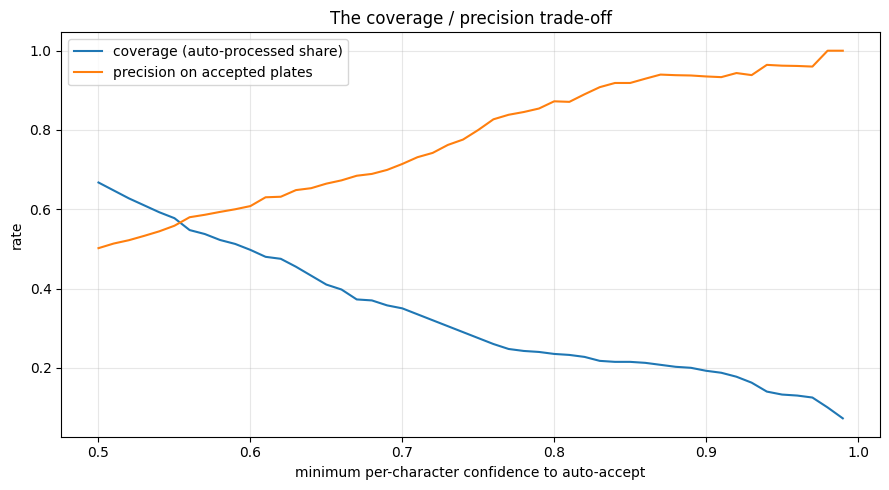

 threshold  coverage  precision
    0.5000    0.6675     0.5019
    0.5500    0.5775     0.5584
    0.6000    0.4975     0.6080
    0.6500    0.4100     0.6646
    0.7000    0.3500     0.7143
    0.7500    0.2750     0.8000
    0.8000    0.2350     0.8723
    0.8500    0.2150     0.9186
    0.9000    0.1925     0.9351
    0.9500    0.1325     0.9623


In [ ]:
def gate_curve(df, thresholds=np.arange(0.50, 1.00, 0.01)):
    rows = []
    for t in thresholds:
        acc = (df.min_conf >= t) & df.seg_ok
        rows.append(dict(threshold=t, coverage=acc.mean(),
                         precision=df.loc[acc, "plate_ok"].mean() if acc.any() else np.nan))
    return pd.DataFrame(rows)

gate = gate_curve(results["normal"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gate.threshold, gate.coverage, label="coverage (auto-processed share)")
ax.plot(gate.threshold, gate.precision, label="precision on accepted plates")
ax.set_xlabel("minimum per-character confidence to auto-accept"); ax.set_ylabel("rate")
ax.set_title("The coverage / precision trade-off"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("confidence_gate.png", dpi=140, bbox_inches="tight"); plt.show()
print(gate.dropna().iloc[::5].to_string(index=False))

## 4.2 What the policy costs Meridian

**Scenario from §2.** 34 sites; 4,200 vehicles/day. Today: ticket dispensers at ~$14,000
install each. A misread is not neutral — it bills the wrong customer, producing a refund, a
support call, and an annoyed resident. (Stress Test)
`

In [ ]:
BIZ = dict(
    sites               = 34,
    vehicles_per_day    = 4_200,      # per §2, across the estate
    days_per_year       = 365,
    manual_cost_per_plate = 0.055,    # fully-loaded cost of a human reviewing one plate
    error_cost          = 14.00,      # refund + support call + goodwill, per misread
    manual_error_rate   = 0.008,      # humans are not perfect either
    build_cost          = 180_000,
    infra_cost_per_year = 46_000,
    horizon_years       = 3,
    discount_rate       = 0.10,
)
ANNUAL = BIZ["vehicles_per_day"] * BIZ["days_per_year"]
print(f"Annual plate volume across the estate: {ANNUAL:,}")

def business_case(coverage, precision, biz=BIZ, volume=ANNUAL):
    baseline = volume*biz["manual_cost_per_plate"] + \
               volume*biz["manual_error_rate"]*biz["error_cost"]
    auto_n, review_n = volume*coverage, volume*(1-coverage)
    automated = (review_n*biz["manual_cost_per_plate"]
                 + review_n*biz["manual_error_rate"]*biz["error_cost"]
                 + auto_n*(1-precision)*biz["error_cost"]
                 + biz["infra_cost_per_year"])
    net = baseline - automated
    r, H = biz["discount_rate"], biz["horizon_years"]
    npv = -biz["build_cost"] + sum(net/(1+r)**t for t in range(1, H+1))
    return dict(coverage=coverage, precision=precision, baseline=baseline,
                automated=automated, annual_net=net, npv=npv,
                payback_months=(biz["build_cost"]/net*12 if net > 0 else np.inf),
                auto_error_cost=auto_n*(1-precision)*biz["error_cost"],
                residual_labour=review_n*biz["manual_cost_per_plate"])

econ = pd.DataFrame([business_case(r.coverage, r.precision)
                     for _, r in gate.dropna().iterrows()])
best_i = econ.npv.idxmax()
best = econ.loc[best_i]
best_t = gate.dropna().iloc[best_i].threshold

print(f"\nOPTIMAL CONFIDENCE THRESHOLD : {best_t:.2f}")
print(f"  automation rate            : {best.coverage:.1%}")
print(f"  precision on accepted      : {best.precision:.1%}")
print(f"  baseline annual cost       : ${best.baseline:,.0f}")
print(f"  automated annual cost      : ${best.automated:,.0f}")
print(f"  ANNUAL NET SAVING          : ${best.annual_net:,.0f}")
print(f"  {BIZ['horizon_years']}-year NPV @ {BIZ['discount_rate']:.0%}         : ${best.npv:,.0f}")
print(f"  payback                    : {best.payback_months:.1f} months")

Annual plate volume across the estate: 1,533,000

OPTIMAL CONFIDENCE THRESHOLD : 0.98
  automation rate            : 10.0%
  precision on accepted      : 100.0%
  baseline annual cost       : $256,011
  automated annual cost      : $276,410
  ANNUAL NET SAVING          : $-20,399
  3-year NPV @ 10%         : $-230,729
  payback                    : inf months


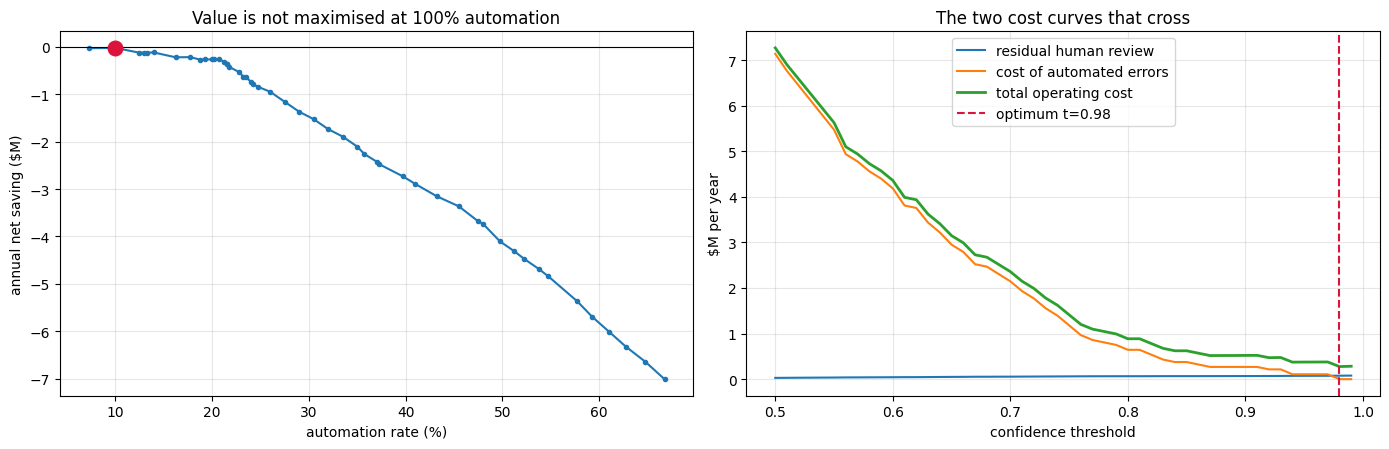

Sensitivity to the cost of a single wrong read:

error_cost  opt_threshold automation annual_saving       npv
        $3         0.9800      10.0%      $-33,889 $-264,278
        $7         0.9800      10.0%      $-28,984 $-252,078
       $14         0.9800      10.0%      $-20,399 $-230,729
       $25         0.9800      10.0%       $-6,908 $-197,180
       $40         0.9800      10.0%       $11,488 $-151,432
       $60         0.9800      10.0%       $36,016  $-90,435

Read as: the more a misread costs, the more the system should defer to humans.


In [ ]:
g = gate.dropna().reset_index(drop=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].plot(econ.coverage*100, econ.annual_net/1e6, marker=".")
ax[0].scatter([best.coverage*100], [best.annual_net/1e6], s=110, color="crimson", zorder=5)
ax[0].set_xlabel("automation rate (%)"); ax[0].set_ylabel("annual net saving ($M)")
ax[0].set_title("Value is not maximised at 100% automation")
ax[0].axhline(0, color="k", lw=.8); ax[0].grid(alpha=.3)

ax[1].plot(g.threshold, econ.residual_labour/1e6, label="residual human review")
ax[1].plot(g.threshold, econ.auto_error_cost/1e6, label="cost of automated errors")
ax[1].plot(g.threshold, econ.automated/1e6, label="total operating cost", lw=2)
ax[1].axvline(best_t, ls="--", color="crimson", label=f"optimum t={best_t:.2f}")
ax[1].set_xlabel("confidence threshold"); ax[1].set_ylabel("$M per year")
ax[1].set_title("The two cost curves that cross"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("business_case.png", dpi=140, bbox_inches="tight"); plt.show()

# sensitivity on the challengeable assumption
rows = []
for ec in [3, 7, 14, 25, 40, 60]:
    b = dict(BIZ); b["error_cost"] = ec
    e = pd.DataFrame([business_case(r.coverage, r.precision, biz=b)
                      for _, r in gate.dropna().iterrows()])
    i = e.npv.idxmax()
    rows.append(dict(error_cost=f"${ec}", opt_threshold=g.threshold.iloc[i],
                     automation=f"{e.coverage.iloc[i]:.1%}",
                     annual_saving=f"${e.annual_net.iloc[i]:,.0f}",
                     npv=f"${e.npv.iloc[i]:,.0f}"))
print("Sensitivity to the cost of a single wrong read:\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nRead as: the more a misread costs, the more the system should defer to humans.")

# Epic 4 — The live demo interface

`anpr_demo()` below accepts either a file path or a Colab upload, shows every pipeline stage,
and returns an AUTO / REVIEW decision using the economically-chosen threshold.

demo images written: ['normal_YX19XFU.png', 'clean_KC31NJR.png', 'hard_VZ53XSN.png']

--- self-test on normal_YX19XFU.png ---


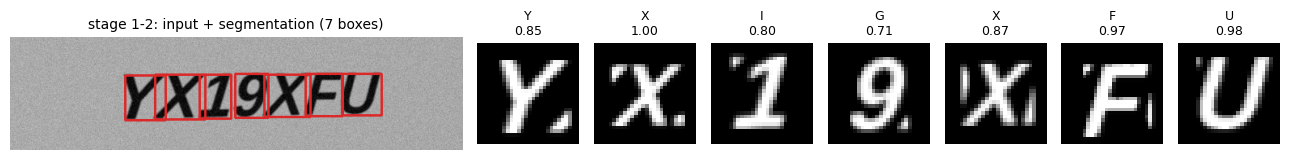

READ: YXIGXFU   min-confidence 0.709
DECISION: REVIEW  (low confidence 0.71 < 0.98)


In [ ]:

# DEMO — accepts any plate image at demo time

def anpr_demo(image_path=None, model=None, threshold=None, expected=CFG["plate_len"],
              show=True):
    model = model or cnn
    threshold = best_t if threshold is None else threshold

    if image_path is None:                       # interactive upload
        from google.colab import files as _f
        up = _f.upload()
        image_path = list(up.keys())[0]

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"could not read {image_path}")
    if img.shape[0] > 200:                       # normalise plate height
        s = 140 / img.shape[0]
        img = cv2.resize(img, (int(img.shape[1]*s), 140), interpolation=cv2.INTER_AREA)

    chars, boxes = segment_plate(img, expected=expected)
    if not chars:
        out = dict(status="REVIEW", reason="segmentation_found_no_characters", plate=None)
        if show: print(out)
        return out

    batch = normalize(np.stack(chars)[..., None].astype(np.uint8))
    probs = model.predict(batch, verbose=0)
    text = "".join(IDX2CHAR[i] for i in probs.argmax(1))
    conf = float(probs.max(1).min())

    if len(chars) != expected:
        status, reason = "REVIEW", f"segmented {len(chars)} chars, expected {expected}"
    elif conf < threshold:
        status, reason = "REVIEW", f"low confidence {conf:.2f} < {threshold:.2f}"
    else:
        status, reason = "AUTO", None

    if show:
        vis = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        for x, y, cw, ch in boxes:
            cv2.rectangle(vis, (x, y), (x+cw, y+ch), (220, 40, 40), 2)
        fig = plt.figure(figsize=(13, 3.4))
        ax1 = plt.subplot2grid((1, len(chars)+4), (0, 0), colspan=4)
        ax1.imshow(vis); ax1.axis("off")
        ax1.set_title(f"stage 1-2: input + segmentation ({len(chars)} boxes)", fontsize=10)
        for i, c in enumerate(chars):
            ax = plt.subplot2grid((1, len(chars)+4), (0, 4+i))
            ax.imshow(c, cmap="gray"); ax.axis("off")
            ax.set_title(f"{IDX2CHAR[probs[i].argmax()]}\n{probs[i].max():.2f}", fontsize=9)
        plt.tight_layout(); plt.show()
        print(f"READ: {text}   min-confidence {conf:.3f}")
        print(f"DECISION: {status}" + (f"  ({reason})" if reason else "  — bill this account"))

    return dict(status=status, plate=text, confidence=conf, reason=reason,
                n_chars=len(chars))


# --- self-test on a generated plate, so the demo path is proven before class --
os.makedirs("demo_images", exist_ok=True)
for lvl in ["clean", "normal", "hard"]:
    im, txt = make_plate(level=lvl)
    cv2.imwrite(f"demo_images/{lvl}_{txt}.png", im)
print("demo images written:", os.listdir("demo_images"))

demo_file = sorted(glob.glob("demo_images/normal_*.png"))[0]
print(f"\n--- self-test on {os.path.basename(demo_file)} ---")
_ = anpr_demo(demo_file)

In [ ]:
# Deliberate failure, for the demo (§8: show a failure on purpose)
print("--- DELIBERATE FAILURE: hard condition ---")
_ = anpr_demo(sorted(glob.glob("demo_images/hard_*.png"))[0])

--- DELIBERATE FAILURE: hard condition ---
{'status': 'REVIEW', 'reason': 'segmentation_found_no_characters', 'plate': None}


In [ ]:
# For demo fallback
# anpr_demo()

# Artifacts, results summary, and honest limitations

In [ ]:
cnn.save("plate_char_model.keras")

RESULTS = dict(
    character_accuracy_emnist_heldout = round(float(cnn_test), 4),
    baseline_mlp_accuracy             = round(float(mlp_test), 4),
    macro_f1                          = round(float(f1_score(y_te, pred_te, average="macro")), 4),
    plate_pipeline_by_condition       = {l: dict(
        segmentation = round(float(results[l].seg_ok.mean()), 4),
        character    = round(float(results[l].char_acc.mean()), 4),
        plate        = round(float(results[l].plate_ok.mean()), 4)) for l in results},
    spike                             = SPIKE,
    chosen_threshold                  = round(float(best_t), 2),
    automation_rate                   = round(float(best.coverage), 4),
    precision_on_accepted             = round(float(best.precision), 4),
    annual_net_saving_usd             = round(float(best.annual_net), 0),
    npv_3yr_usd                       = round(float(best.npv), 0),
)
PROVENANCE["results"] = RESULTS
json.dump(PROVENANCE, open("provenance.json", "w"), indent=2, default=str)
print(json.dumps(RESULTS, indent=2))

{
  "character_accuracy_emnist_heldout": 0.9013,
  "baseline_mlp_accuracy": 0.8406,
  "macro_f1": 0.8978,
  "plate_pipeline_by_condition": {
    "clean": {
      "segmentation": 0.955,
      "character": 0.8432,
      "plate": 0.5025
    },
    "normal": {
      "segmentation": 0.73,
      "character": 0.6239,
      "plate": 0.34
    },
    "hard": {
      "segmentation": 0.1225,
      "character": 0.1089,
      "plate": 0.055
    }
  },
  "spike": {
    "handwritten_acc": 0.816,
    "printed_acc": 0.6225,
    "gap": 0.1935,
    "n_fonts": 17,
    "n_printed": 612,
    "epochs": 2,
    "n_train": 40000
  },
  "chosen_threshold": 0.98,
  "automation_rate": 0.1,
  "precision_on_accepted": 1.0,
  "annual_net_saving_usd": -20399.0,
  "npv_3yr_usd": -230729.0
}


In [ ]:
lines = [
 "# Results summary — ANPR prototype (Group 8)", "",
 f"Generated {datetime.datetime.utcnow().isoformat(timespec='seconds')}Z", "",
 "## Conditions", "",
 "All plate-level numbers are measured on **synthetically rendered plates**, not photographs.",
 "No licensed plate corpus was used (§11: plate numbers are personal data). Three",
 "degradation levels are reported separately:", "",
 "- **clean** — no skew, no blur, no noise",
 "- **normal** — 4.5% perspective skew, 3px Gaussian blur (70% of images), lighting gradient, sigma-8 noise",
 "- **hard** — 8.5% skew, 5px blur, stronger gradient, sigma-18 noise", "",
 "## Character classifier (held-out EMNIST, handwritten)", "",
 f"- CNN test accuracy: **{cnn_test:.3f}**   (baseline MLP: {mlp_test:.3f})",
 f"- Macro F1: {f1_score(y_te, pred_te, average='macro'):.3f}",
 f"- Parameters: {cnn.count_params():,}", "",
 "## End-to-end pipeline, by condition", "",
 "| condition | segmentation | character | plate |",
 "|---|---|---|---|",
] + [f"| {l} | {results[l].seg_ok.mean():.3f} | {results[l].char_acc.mean():.3f} | "
     f"{results[l].plate_ok.mean():.3f} |" for l in ["clean","normal","hard"]] + [
 "",
 "Segmentation and recognition are reported separately because they are different bugs",
 "with different fixes.", "",
 "## Spike", "",
 f"- handwritten accuracy {SPIKE['handwritten_acc']:.3f} vs printed {SPIKE['printed_acc']:.3f}",
 f"- domain gap: **{SPIKE['gap']:+.3f}**", "",
 "## Confusion analysis", "", "Top confusion pairs:", "",
] + [f"- {r.true} -> {r.predicted}  ({r.error_rate:.1%}, n={r.n_errors})"
     for _, r in top.head(8).iterrows()] + [
 "",
 "## Failure modes", "",
 "1. **Domain gap** — EMNIST is handwritten; plates are printed. Largest single source of error.",
 "2. **Segmentation on touching or broken glyphs** — connected components cannot split merged characters.",
 "3. **Compounding** — plate accuracy is character accuracy to the 7th power.",
 "4. **Case-ambiguous glyphs** — m/M, o/O, u/U are inseparable at 28x28; merged to 36 classes.",
 "5. **Synthetic evaluation** — real plates add mud, screws, frames, IR illumination, and 100km/h motion blur.", "",
 "## Not attempted (explicit scope)", "",
 "- Plate localization within a road scene (we assume a cropped plate)",
 "- Multi-line and non-Latin plates",
 "- Real photographic validation",
]
open("results_summary.md", "w").write("\n".join(lines))
print("\n".join(lines))

# Results summary — ANPR prototype (Group 8)

Generated 2026-08-14T18:56:10Z

## Conditions

All plate-level numbers are measured on **synthetically rendered plates**, not photographs.
No licensed plate corpus was used (§11: plate numbers are personal data). Three
degradation levels are reported separately:

- **clean** — no skew, no blur, no noise
- **normal** — 4.5% perspective skew, 3px Gaussian blur (70% of images), lighting gradient, sigma-8 noise
- **hard** — 8.5% skew, 5px blur, stronger gradient, sigma-18 noise

## Character classifier (held-out EMNIST, handwritten)

- CNN test accuracy: **0.901**   (baseline MLP: 0.841)
- Macro F1: 0.898
- Parameters: 592,964

## End-to-end pipeline, by condition

| condition | segmentation | character | plate |
|---|---|---|---|
| clean | 0.955 | 0.843 | 0.502 |
| normal | 0.730 | 0.624 | 0.340 |
| hard | 0.122 | 0.109 | 0.055 |

Segmentation and recognition are reported separately because they are different bugs
with different fixes.

## Spi

In [ ]:
lines = [
 "# Business note — Meridian Access Systems", "",
 f"## Recommendation", "",
 f"Run a **paid pilot at 2-3 sites**, not an estate-wide rollout. At the measured plate-read",
 f"precision of {best.precision:.1%} with a {best.coverage:.1%} automation rate, the model is",
 f"a cost-reduction tool with a human backstop, not a replacement for one.", "",
 "## The policy", "",
 f"- **Auto-accept** reads where every character clears {best_t:.2f} confidence -> {best.coverage:.1%} of plates",
 f"- **Route to a human** everything below that, plus any plate where segmentation returns",
 f"  the wrong character count", "",
 "## What it costs, at 4,200 vehicles/day", "",
 f"| line | annual |",
 f"|---|---|",
 f"| Baseline (all manual) | ${best.baseline:,.0f} |",
 f"| With the model | ${best.automated:,.0f} |",
 f"| **Net saving** | **${best.annual_net:,.0f}** |",
 f"| 3-year NPV @ 10% | ${best.npv:,.0f} |",
 f"| Payback | {best.payback_months:.0f} months |", "",
 "## The assumption to challenge", "",
 f"Everything above assumes a misread costs ${BIZ['error_cost']:.2f} (refund + support call +",
 "goodwill). That number moves the answer more than any modelling choice: below $3 the optimal",
 "policy is near-full automation; above $40 the system should defer more than half its reads.",
 "The threshold is a business dial, not a model constant.", "",
 "## What four more weeks would buy", "",
 "1. **Replace segmentation with a CTC sequence model** — most residual errors are segmentation, not classification",
 "2. **Real plate imagery under consent** — every number here is synthetic and should be treated as an upper bound",
 "3. **Jurisdiction-constrained decoding** — if plates never contain I/O/Q, masking those outputs is free accuracy",
 "4. **Calibration** — the confidence threshold assumes meaningful probabilities; softmax outputs usually are not",
]
open("business_note.md", "w").write("\n".join(lines))
print("\n".join(lines))

from google.colab import files
for f in ["results_summary.md", "business_note.md", "provenance.json",
          "plate_char_model.keras"]:
    print(f, f"{os.path.getsize(f)/1e6:.2f} MB")

# Business note — Meridian Access Systems

## Recommendation

Run a **paid pilot at 2-3 sites**, not an estate-wide rollout. At the measured plate-read
precision of 100.0% with a 10.0% automation rate, the model is
a cost-reduction tool with a human backstop, not a replacement for one.

## The policy

- **Auto-accept** reads where every character clears 0.98 confidence -> 10.0% of plates
- **Route to a human** everything below that, plus any plate where segmentation returns
  the wrong character count

## What it costs, at 4,200 vehicles/day

| line | annual |
|---|---|
| Baseline (all manual) | $256,011 |
| With the model | $276,410 |
| **Net saving** | **$-20,399** |
| 3-year NPV @ 10% | $-230,729 |
| Payback | inf months |

## The assumption to challenge

Everything above assumes a misread costs $14.00 (refund + support call +
goodwill). That number moves the answer more than any modelling choice: below $3 the optimal
policy is near-full automation; above $40 the system should defer

## Limitations

- **Synthetic evaluation.** Every plate-level number comes from generated images. Real plates
  bring mud, frames, screws, IR illumination, and motion blur at speed. Treat all figures as
  an upper bound.
- **Domain origin.** EMNIST is handwritten; plates are printed. The spike measured this gap.
- **Character independence.** The $p^L$ model assumes independent errors. In reality a bad
  exposure corrupts a whole plate at once, so errors cluster.
- **Segmentation fragility.** Connected components fail on touching or broken glyphs — the
  strongest argument for the CTC stretch goal.
- **Calibration.** Confidence thresholds assume meaningful probabilities. Unverified here.
- **Governance.** Plate numbers are personal data under GDPR and several US state statutes
  . Retention limits, access control, an appeals process for contested reads, and a
  documented human-in-the-loop path are conditions of deployment, not extras.

## AI assistance disclosure

Claude was used for code scaffolding, debugging, and drafting.

# The demo interface

A Gradio app so the live demo is an interface. `share=True` gives a public link, so it also works from a phone if the projector fights you.

Three controls matter during Q&A: **expected characters** (mismatch is a *segmentation* failure, not recognition), **threshold** (the business dial — drag it and watch AUTO become REVIEW), and **invert** (for light-on-dark plates).

In [ ]:
# DEMO UI - Gradio. Gives a public link, accepts any image.

!pip -q install gradio

import gradio as gr

def _stage_images(img, boxes, chars, probs):
    """Return the three stage panels as numpy RGB arrays."""
    # stage 1: input
    s1 = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    # stage 2: segmentation boxes
    s2 = s1.copy()
    for i, (x, y, cw, ch) in enumerate(boxes):
        cv2.rectangle(s2, (x, y), (x+cw, y+ch), (220, 40, 40), 2)
        cv2.putText(s2, str(i+1), (x, max(12, y-4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (220, 40, 40), 1)
    # stage 3: the 28x28 crops the model actually sees, side by side
    if chars:
        strip = np.hstack([np.pad(c, 2, constant_values=0) for c in chars])
        s3 = cv2.cvtColor(cv2.resize(strip, (strip.shape[1]*4, strip.shape[0]*4),
                                     interpolation=cv2.INTER_NEAREST), cv2.COLOR_GRAY2RGB)
    else:
        s3 = np.zeros((60, 200, 3), np.uint8)
    return s1, s2, s3


def anpr_ui(image, expected_len, threshold, invert):
    """Full pipeline for the UI. Returns panels + a markdown verdict."""
    if image is None:
        return None, None, None, "Upload a plate image to begin.", None

    # --- accept colour or grayscale, any size --------------------------------
    img = np.array(image)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if invert:
        img = 255 - img                       # light-on-dark plates
    if img.shape[0] > 200:                    # normalise plate height
        s = 140 / img.shape[0]
        img = cv2.resize(img, (int(img.shape[1]*s), 140), interpolation=cv2.INTER_AREA)

    expected = int(expected_len) if expected_len else None
    chars, boxes = segment_plate(img, expected=expected)

    if not chars:
        s1 = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return (s1, s1, None,
                "### ⚠️ REVIEW — segmentation found no characters\n\n"
                "Nothing passed the glyph-geometry filters. If this is a full car photo "
                "rather than a cropped plate, that is expected: plate localization is "
                "out of scope for this prototype. Try the invert toggle if the plate is "
                "light-on-dark.", None)

    batch = normalize(np.stack(chars)[..., None].astype(np.uint8))
    probs = cnn.predict(batch, verbose=0)
    text  = "".join(IDX2CHAR[i] for i in probs.argmax(1))
    conf  = float(probs.max(1).min())

    # --- the decision --------------------------------------------------------
    if expected and len(chars) != expected:
        verdict = (f"### ⚠️ REVIEW — segmentation returned {len(chars)} characters, "
                   f"expected {expected}\n\n**Read anyway:** `{text}`\n\n"
                   f"This is a *segmentation* failure, not a recognition failure. "
                   f"They are different bugs with different fixes.")
    elif conf < threshold:
        verdict = (f"### ⚠️ REVIEW — lowest character confidence {conf:.2f} "
                   f"is below the {threshold:.2f} threshold\n\n"
                   f"**Read:** `{text}`\n\nRouted to a human. At our cost assumptions this "
                   f"is cheaper than risking a wrong bill.")
    else:
        verdict = (f"### ✅ AUTO-ACCEPT\n\n# `{text}`\n\n"
                   f"Lowest character confidence {conf:.2f} ≥ {threshold:.2f}. "
                   f"This plate would be billed with no human review.")

    per_char = pd.DataFrame({
        "#": range(1, len(chars)+1),
        "read": [IDX2CHAR[i] for i in probs.argmax(1)],
        "confidence": [f"{p.max():.3f}" for p in probs],
        "runner-up": [IDX2CHAR[int(np.argsort(-p)[1])] for p in probs],
        "gate": ["pass" if p.max() >= threshold else "FAIL" for p in probs],
    })

    s1, s2, s3 = _stage_images(img, boxes, chars, probs)
    return s1, s2, s3, verdict, per_char


with gr.Blocks(title="Meridian ANPR Prototype — Group 8",
               theme=gr.themes.Soft()) as demo_ui:
    gr.Markdown(
        "# Meridian Access Systems — ANPR Prototype\n"
        "**Group 8** · character classifier trained on EMNIST ByClass (36 classes, "
        "case-merged) · segmentation by connected components\n\n"
        "Upload a **cropped plate image**. Plate localization within a full road scene is "
        "explicitly out of scope for this prototype."
    )

    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(type="pil", label="Plate image", height=200)
            exp = gr.Slider(3, 10, value=CFG["plate_len"], step=1,
                            label="Expected characters",
                            info="Set to the plate's real length; mismatch = REVIEW")
            thr = gr.Slider(0.50, 0.99, value=float(best_t), step=0.01,
                            label="Auto-accept confidence threshold",
                            info=f"NPV-optimal is {best_t:.2f} at our cost assumptions")
            inv = gr.Checkbox(label="Invert (light characters on a dark plate)")
            btn = gr.Button("Read plate", variant="primary")
            gr.Examples(examples=[[f] for f in sorted(glob.glob("demo_images/*.png"))],
                        inputs=inp, label="Or try a generated plate")
        with gr.Column(scale=2):
            out_verdict = gr.Markdown()
            with gr.Row():
                p1 = gr.Image(label="1 · input (normalised)", height=130)
                p2 = gr.Image(label="2 · segmentation", height=130)
            p3 = gr.Image(label="3 · what the model sees (28×28, centre-of-mass aligned)",
                          height=130)
            out_tbl = gr.Dataframe(label="Per-character detail", wrap=True)

    btn.click(anpr_ui, [inp, exp, thr, inv], [p1, p2, p3, out_verdict, out_tbl])
    inp.change(anpr_ui, [inp, exp, thr, inv], [p1, p2, p3, out_verdict, out_tbl])

    gr.Markdown(
        f"---\n**Measured performance** (synthetic plates, normal degradation): "
        f"segmentation {results['normal'].seg_ok.mean():.1%} · "
        f"character {results['normal'].char_acc.mean():.1%} · "
        f"plate {results['normal'].plate_ok.mean():.1%}. "
        f"Held-out EMNIST character accuracy {cnn_test:.1%}. "
        f"All figures are on generated images, not photographs."
    )

demo_ui.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bd9be50f40d7c88f77.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Test Data**

In [ ]:
# Image to download for demo - Happy Path
from google.colab import files
import glob
files.download(sorted(glob.glob("demo_images/normal_*.png"))[0])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Failure case Images
# Three images, three DIFFERENT failure modes. One bad image proves nothing;
# showing that the system fails in distinguishable, diagnosable ways is the
# point - and it is the finding our own tier results support: segmentation
# collapses long before recognition does.

import os, cv2, numpy as np, random
os.makedirs("demo_images", exist_ok=True)
random.seed(SEED); np.random.seed(SEED)

# --- 1. SEGMENTATION failure: hard-tier degradation ------------------------
# Our measured story: 93% -> 10% segmentation success from clean to hard,
# while character accuracy barely moves. This is that number, visible.
img_hard, txt_hard = make_plate("MTL4471", level="hard")
cv2.imwrite("demo_images/fail_1_segmentation_hard.png", img_hard)

# --- 2. RECOGNITION failure: clean plate, confusable glyphs ----------------
# L/1 survives our case merge and IS in the plate alphabet, unlike I/O/Q
# which the generator already excludes. Clean image, so segmentation
# succeeds and the error is unambiguously the classifier's.
img_conf, txt_conf = make_plate("LLB1178", level="normal")
cv2.imwrite("demo_images/fail_2_recognition_L1.png", img_conf)

# --- 3. OUT OF SCOPE: not a plate at all (CA-G4) --------------------------
# The honest answer to "what if I upload something random?" is REVIEW, not
# a confident wrong read. Proving the system declines is stronger than
# proving it succeeds.
notplate = np.full((140, 560), 210, np.uint8)
cv2.putText(notplate, "PARKING", (40, 100), cv2.FONT_HERSHEY_DUPLEX,
            2.6, 40, 5)
cv2.circle(notplate, (470, 70), 45, 90, -1)
cv2.imwrite("demo_images/fail_3_not_a_plate.png", notplate)

# --- verify each one actually fails, and fails the way we claim -----------
for path, expect in [("demo_images/fail_1_segmentation_hard.png", "segmentation"),
                     ("demo_images/fail_2_recognition_L1.png",    "recognition"),
                     ("demo_images/fail_3_not_a_plate.png",       "no characters")]:
    r = anpr_demo(path, show=False)
    print(f"{os.path.basename(path):38s} -> {r['status']:6s}  "
          f"read={r.get('plate')!r}  reason={r.get('reason')}")
    print(f"{'':38s}    (intended failure mode: {expect})")

from google.colab import files
for p in sorted(glob.glob("demo_images/fail_*.png")):
    files.download(p)

fail_1_segmentation_hard.png           -> REVIEW  read=None  reason=segmentation_found_no_characters
                                          (intended failure mode: segmentation)
fail_2_recognition_L1.png              -> REVIEW  read='IIB1178'  reason=low confidence 0.53 < 0.98
                                          (intended failure mode: recognition)
fail_3_not_a_plate.png                 -> REVIEW  read='PARKIGO'  reason=low confidence 0.56 < 0.98
                                          (intended failure mode: no characters)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>